### Step 01 - Initialise Paths and Consolidate Source Feeds

**Objective:** Establish a reproducible working directory, declare all source file locations, and assemble every crawler export into a single master dataframe.

**Rationale:** Production analytics work should preserve source lineage before any cleaning starts. The added `dataset` and `source_file` fields make it possible to trace anomalies, duplicates, or translation issues back to the exact crawl batch that produced them.

**How to review this cell:** Confirm the combined row count is plausible relative to the input files, then spot-check the preview to verify that `dataset`, `query`, and `title` were loaded correctly across all source folders.

In [ ]:
from pathlib import Path
import re
from urllib.parse import parse_qsl, urlencode, urlsplit, urlunsplit

import numpy as np
import pandas as pd

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / 'combine.ipynb').exists():
    NOTEBOOK_DIR = Path(r'd:\\ANALYTICS\\WEBCRAWL\\final')

ROOT_DIR = NOTEBOOK_DIR.parent
OUTPUT_DIR = NOTEBOOK_DIR / 'combined_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_FILES = {
    'web1': ROOT_DIR / 'data' / 'ai_chatbot_companion_news_sentiment.csv',
    'web2': ROOT_DIR / 'data' / 'ai_chatbot_companion_news_sentiment1.csv',
    'part2': ROOT_DIR / 'data' / 'ai_companionship_news_sentiment.csv',
    'part3': ROOT_DIR / 'data' / 'ai_companionship_news_sentiment1.csv',
    'part4': ROOT_DIR / 'data' / 'ai_companionship_news_sentiment2.csv',
    'part5': ROOT_DIR / 'data' / 'ai_companionship_news_sentiment3.csv',
    'part6': ROOT_DIR / 'data' / 'ai_companionship_news_sentiment4.csv',
    'part7': ROOT_DIR / 'data' / 'ai_companionship_news_sentiment5.csv',
    'part8': ROOT_DIR / 'data' / 'ai_companionship_news_sentiment6.csv',
    'part9': ROOT_DIR / 'data' / 'ai_companionship_news_sentiment7.csv',
    'part10': ROOT_DIR / 'data' / 'ai_companionship_news_sentiment8.csv',
    'japan': ROOT_DIR / 'data' / 'ai_companion_japan_news_sentiment.csv',
    'webusa': ROOT_DIR / 'data' / 'ai_companion_US_news_sentiment.csv',
}

frames = []
for dataset, file_path in SOURCE_FILES.items():
    frame = pd.read_csv(file_path)
    frame['dataset'] = dataset
    frame['source_file'] = str(file_path)
    frames.append(frame)

combined_raw_df = pd.concat(frames, ignore_index=True, sort=False)
print('Combined rows before cleaning:', len(combined_raw_df))
combined_raw_df[['dataset', 'query', 'title']].head(10)

Combined rows before cleaning: 6863


,dataset,query,title
0,web1,ChatGPT news,Google News
1,web1,chatbot AI,Google News
2,web1,ChatGPT news,Google News
3,web1,ChatGPT news,Google News
4,web1,conversational AI,Google News
5,web1,AI chatbot,Google News
6,web1,conversational AI,Google News
7,web1,conversational AI,Google News
8,web1,AI companion recent news,Google News
9,web1,AI chatbot,Google News


# Strict Combined AI Companionship News Pipeline

This notebook is the production-grade workflow for combining, cleaning, and analysing the strict AI companionship news corpus. It starts with multi-source ingestion, applies auditable relevance and quality controls, and then produces sentiment, vocabulary, topic, and network artefacts for downstream reporting.

**Execution guidance:** Run the notebook from top to bottom for a full rebuild. If the kernel resets after topic modelling, use the later reload cell to resume from saved CSV artefacts instead of retraining the entire pipeline.

**Project standard:** The workflow is designed for lineage, repeatability, and reviewability. Intermediate exports, explicit removal reasons, deterministic parameters, and topic-level evidence tables make the notebook suitable for professional delivery, governance review, and handoff to other analysts.

### Step 02 - Define Strict Cleaning Rules and Relevance Heuristics

**Objective:** Centralise the text-normalisation logic, URL canonicalisation rules, boilerplate trimming, and topic-relevance heuristics used by the strict corpus.

**Rationale:** Keeping these rules in one cell turns the cleaning policy into something explicit and reviewable. That is important for an industry-ready pipeline because inclusion criteria, exclusion criteria, and deduplication logic should be explainable to reviewers and reproducible by other analysts.

**How to review this cell:** Read the regex patterns as the formal definition of what counts as relevant AI companionship coverage versus research portals, device noise, and generic boilerplate. These helper functions are reused by the downstream cleaning stage.

In [72]:
FOOTER_MARKERS = [
    'privacy policy',
    'cookie policy',
    'all rights reserved',
    'sign up',
    'subscribe now',
    'subscribe to',
    'register to comment',
    'accedi o registrati',
    'latest world & national news',
    'follow us on',
    'download our app',
    'newsletter',
    'terms of use',
    'terms and conditions',
]

SPECIFIC_COMPANION_PATTERN = re.compile(
    r'\b('
    r'ai companion|digital companion|virtual companion|ai partner|virtual partner|'
    r'companion app|companion chatbot|ai chatbot companion|'
    r'ai girlfriend|ai boyfriend|virtual girlfriend|virtual boyfriend|'
    r'ai friend|virtual friend|chatbot friend|ai wife|ai husband|'
    r'dating chatbot|romantic chatbot|relationship chatbot|'
    r'emotional support chatbot|therapy chatbot|mental health chatbot|'
    r'roleplay ai|roleplay chatbot|interactive ai character|ai marriage|'
    r'parasocial ai|ai relationship|human ai relationship|ai chatbot|'
    r'replika|character\.ai|kindroid|nomi|anima|chai|janitor ai|ai pet'
    r')\b',
    flags=re.IGNORECASE,
)
AI_CONTEXT_PATTERN = re.compile(
    r'\b('
    r'ai|chatbot|chatbots|bot|bots|llm|gpt|language model|'
    r'generative ai|conversational ai|dialogue system|'
    r'virtual|digital|synthetic|avatar|persona|character ai|'
    r'replika|character\.ai|kindroid|nomi|anima|chai'
    r')\b',
    flags=re.IGNORECASE,
)
COMPANION_CONTEXT_PATTERN = re.compile(
    r'\b('
    r'companion|companionship|partner|relationship|relationships|'
    r'girlfriend|boyfriend|friendship|friend|assistant|'
    r'loneliness|lonely|alone|isolation|social isolation|'
    r'emotional support|emotional attachment|attachment|affection|'
    r'love|romance|romantic|dating|intimacy|sexual|nsfw|marry|marriage|'
    r'parasocial|connection|bond|bonding|human ai relationship|'
    r'mental health|therapy|therapeutic|wellbeing|'
    r'comfort|support|validation|empathy|empathetic|'
    r'roleplay|fantasy|simulation|interaction|conversation|immersive|interactive|'
    r'addiction|dependency|obsession|depression|suicide|depressed|coping'
    r')\b',
    flags=re.IGNORECASE,
)
RESEARCH_PORTAL_PATTERN = re.compile(
    r'arxivlabs|alphaxiv|litmaps|catalyzex|dagshub|sciencecast|bibliographic|citation|arxiv',
    flags=re.IGNORECASE,
)
DEVICE_NOISE_PATTERN = re.compile(
    r'\b(?:'
    r'ipad|wearable|watch|smartwatch|earbuds|headphones|computer|'
    r'camera|lens|sensor|display|screen|battery|chip|processor|gpu|cpu|'
    r'qualcomm|snapdragon|exynos|mediatek|linux|kernal|audio|power|'
    r'hardware|specs|specifications|benchmark|performance|'
    r'pricing|price|hands-on|movie|film|game'
    r')\b',
    flags=re.IGNORECASE,
)


def normalize_whitespace(text):
    if pd.isna(text):
        return ''
    return re.sub(r'\s+', ' ', str(text)).strip()

def canonicalize_url(url):
    if pd.isna(url) or not str(url).strip():
        return ''
    parsed = urlsplit(str(url).strip())
    filtered_query = [
        (key, value)
        for key, value in parse_qsl(parsed.query, keep_blank_values=True)
        if key.lower() not in {'utm_source', 'utm_medium', 'utm_campaign', 'utm_term', 'utm_content', 'oc', 'hl', 'gl', 'ceid'}
    ]
    clean_path = parsed.path.rstrip('/') or parsed.path
    return urlunsplit((parsed.scheme.lower(), parsed.netloc.lower(), clean_path, urlencode(filtered_query), ''))

def strip_boilerplate(text):
    clean = normalize_whitespace(text)
    if not clean:
        return ''
    lower = clean.lower()
    cut_positions = []
    for marker in FOOTER_MARKERS:
        position = lower.find(marker)
        if position >= 300:
            cut_positions.append(position)
    if cut_positions:
        clean = clean[: min(cut_positions)].strip(' -|,.;')
    clean = re.sub(r'Just a moment\. We are getting your experience ready\.\s*', '', clean, flags=re.IGNORECASE)
    clean = re.sub(r'(Comprehensive up-to-date news coverage, aggregated from sources all over the world by Google News\.?\s*)+', '', clean, flags=re.IGNORECASE)
    return normalize_whitespace(clean)

def is_ai_companion_related(query, title, text):
    combined = f'{title} {text}'.strip()
    query_text = query or ''
    if SPECIFIC_COMPANION_PATTERN.search(combined) or SPECIFIC_COMPANION_PATTERN.search(query_text):
        return True
    return bool(AI_CONTEXT_PATTERN.search(combined) and COMPANION_CONTEXT_PATTERN.search(combined))


### Step 03 - Translate Non-English Coverage into a Common Analysis Language

**Objective:** Detect article language and translate non-English text fields into English before strict relevance filtering and downstream NLP analysis.

**Rationale:** A multinational corpus is valuable only if the pipeline can compare documents on a common linguistic basis. Translating before cleaning reduces the chance that relevant Japanese, European, or other international coverage is misclassified simply because the relevance rules and topic models operate in English.

**How to review this cell:** Check the count of translated rows and the language distribution table. The use of caching and a fixed seed improves consistency, while the fallback logic protects the notebook from failing when translation returns an empty or invalid response.

In [74]:
# Translate non-English rows to English before strict cleaning
%pip install -q langdetect deep-translator

from deep_translator import GoogleTranslator
from langdetect import DetectorFactory, LangDetectException, detect
from tqdm.auto import tqdm

DetectorFactory.seed = 42
tqdm.pandas()

TRANSLATABLE_COLUMNS = [col for col in ['query', 'title', 'text', 'summary', 'description'] if col in combined_raw_df.columns]
translation_df = combined_raw_df.copy()
language_cache = {}
translation_cache = {}
translator = GoogleTranslator(source='auto', target='en')

def safe_detect_language(text):
    text = '' if pd.isna(text) else str(text).strip()
    if not text:
        return 'unknown'
    if text in language_cache:
        return language_cache[text]
    try:
        detected = detect(text)
    except LangDetectException:
        detected = 'unknown'
    language_cache[text] = detected
    return detected

def translate_to_english(text, detected_language):
    text = '' if pd.isna(text) else str(text).strip()
    if not text or detected_language in {'en', 'unknown'}:
        return text
    cache_key = (detected_language, text)
    if cache_key in translation_cache:
        return translation_cache[cache_key]
    try:
        translated = translator.translate(text)
        translated = text if translated is None else str(translated).strip()
    except Exception:
        translated = text
    translation_cache[cache_key] = translated
    return translated

if TRANSLATABLE_COLUMNS:
    title_or_text = (
        translation_df.get('title', pd.Series('', index=translation_df.index)).fillna('')
        + ' ' +
        translation_df.get('text', pd.Series('', index=translation_df.index)).fillna('')
    ).str.strip()
    translation_df['detected_language'] = title_or_text.progress_map(safe_detect_language)
    translation_df['was_translated_to_english'] = translation_df['detected_language'].ne('en') & translation_df['detected_language'].ne('unknown')

    for column in TRANSLATABLE_COLUMNS:
        original_col = f'original_{column}'
        translation_df[original_col] = translation_df[column]
        translation_df[column] = [
            translate_to_english(text, lang)
            for text, lang in tqdm(
                zip(translation_df[column], translation_df['detected_language']),
                total=len(translation_df),
                desc=f'Translating {column} to English'
            )
        ]

    translated_rows = int(translation_df['was_translated_to_english'].sum())
    print(f'Rows detected as non-English and translated: {translated_rows}')
    display(translation_df['detected_language'].value_counts().rename_axis('language').reset_index(name='rows').head(15))
    combined_raw_df = translation_df
else:
    print('No translatable text columns found in combined_raw_df.')


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\Neysa\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


  0%|          | 0/6863 [00:00<?, ?it/s]

Translating query to English:   0%|          | 0/6863 [00:00<?, ?it/s]

Translating title to English:   0%|          | 0/6863 [00:00<?, ?it/s]

Translating text to English:   0%|          | 0/6863 [00:00<?, ?it/s]

Rows detected as non-English and translated: 68


,language,rows
0,en,6795
1,de,23
2,it,17
3,ko,15
4,fr,10
5,ca,3


### Step 04 - Apply Strict Filtering, Normalisation, and Deduplication

**Objective:** Create analysis-ready text fields, apply relevance and quality filters, assign explicit removal reasons, and deduplicate records using canonical URLs plus title-text matching.

**Rationale:** This is the core governance cell for the strict dataset. It converts raw crawl output into a defensible analytical corpus by removing low-information pages, off-topic content, duplicate stories, and generic aggregator stubs while keeping the longest and most informative surviving record.

**How to review this cell:** Focus on the final counts for `cleaned_df` and `removed_df`, then inspect the preview to ensure retained rows still represent substantive AI companionship reporting. The explicit `removal_reason` column is critical for auditability and later QA.

In [75]:
df = combined_raw_df.copy()
df['query'] = df.get('query', '').fillna('').astype(str)
df['title'] = df.get('title', '').fillna('').astype(str)
df['text'] = df.get('text', '').fillna('').astype(str)
df['clean_title'] = df['title'].map(normalize_whitespace)
df['clean_text'] = df['text'].map(strip_boilerplate)
df['analysis_text'] = (df['clean_title'] + ' ' + df['clean_text']).str.strip()
df['analysis_length'] = df['analysis_text'].str.len()
df['url_key'] = df.get('final_url', pd.Series(index=df.index, dtype=object)).fillna(df.get('url', '')).map(canonicalize_url)
df['title_key'] = df['clean_title'].str.lower()
df['text_key'] = df['analysis_text'].str.lower().str.replace(r'\s+', ' ', regex=True).str[:1500]

google_stub_mask = (
    df['clean_title'].str.lower().eq('google news')
    & df['clean_text'].str.contains('comprehensive up-to-date news coverage', case=False, na=False)
)
boilerplate_mask = df['analysis_text'].str.contains(
    r'privacy policy|cookie policy|all rights reserved|sign up|subscribe now|register to comment|accedi o registrati|latest world & national news',
    case=False,
    na=False,
)
research_portal_mask = df['analysis_text'].str.contains(RESEARCH_PORTAL_PATTERN, na=False)
device_mask = df['analysis_text'].str.contains(DEVICE_NOISE_PATTERN, na=False)
short_mask = df['analysis_length'] < 50
relevance_mask = [
    is_ai_companion_related(query, title, text)
    for query, title, text in zip(df['query'], df['clean_title'], df['clean_text'])
]

df['removal_reason'] = ''
df.loc[google_stub_mask, 'removal_reason'] = 'generic aggregator stub'
df.loc[(df['removal_reason'] == '') & ~pd.Series(relevance_mask, index=df.index), 'removal_reason'] = 'not AI companion related'
df.loc[(df['removal_reason'] == '') & research_portal_mask, 'removal_reason'] = 'research portal / paper index page'
df.loc[(df['removal_reason'] == '') & short_mask, 'removal_reason'] = 'too short after cleaning'
df.loc[(df['removal_reason'] == '') & device_mask, 'removal_reason'] = 'device hardware review'
#df.loc[(df['removal_reason'] == '') & boilerplate_mask, 'removal_reason'] = 'boilerplate/privacy/signup text'

cleaned_df = df[df['removal_reason'] == ''].copy()
removed_df = df[df['removal_reason'] != ''].copy()

cleaned_df = cleaned_df.sort_values('analysis_length', ascending=False)
duplicate_url_mask = cleaned_df['url_key'].ne('') & cleaned_df.duplicated(subset=['url_key'], keep='first')
duplicate_url_df = cleaned_df[duplicate_url_mask].copy()
duplicate_url_df['removal_reason'] = 'duplicate canonical URL'
cleaned_df = cleaned_df[~duplicate_url_mask].copy()

duplicate_text_mask = cleaned_df.duplicated(subset=['title_key', 'text_key'], keep='first')
duplicate_text_df = cleaned_df[duplicate_text_mask].copy()
duplicate_text_df['removal_reason'] = 'duplicate title/text'
cleaned_df = cleaned_df[~duplicate_text_mask].copy()

removed_df = pd.concat([removed_df, duplicate_url_df, duplicate_text_df], ignore_index=True, sort=False)
cleaned_df = cleaned_df.sort_values(['dataset', 'title']).reset_index(drop=True)
removed_df = removed_df.sort_values(['removal_reason', 'dataset']).reset_index(drop=True)

print('Rows after cleaning:', len(cleaned_df))
print('Rows removed:', len(removed_df))
cleaned_df[['dataset', 'query', 'title']].head(15)

Rows after cleaning: 503
Rows removed: 6360


,dataset,query,title
0,japan,AI chatbot Japan,AI push to reshape Japan's school classrooms | NHK WORLD-JAPAN News
1,japan,AI companion Asia,Can AI cure loneliness? These Asian companies think so
2,japan,ChatGPT Japan,"Cloudflare's report reveals various statistics on the Internet, such as 'ChatGPT is popular in Japan,' '57% of traffic in Japan is iOS devices,' and 'Global traffic will increa..."
3,japan,Japan AI companion market,Concerns rise in Japan about AI deepfakes in jobs market | NHK WORLD-JAPAN News
4,japan,conversational AI Japan,Conversational AI: Friend or foe? | NHK WORLD-JAPAN News
5,japan,AI girlfriend Japan,Dating app full of AI people very popular among 40-something married men in Japan
6,japan,AI chatbot Japan,Emotionally Attached to an Algorithm - The Rise of Deep AI Companionship in Japan.
7,japan,Japan generative AI chatbot,Generative AI rivals racing to the future
8,japan,AI chatbot Japan,Google teams up with Walmart and other retailers to enable shopping within Gemini AI chatbot
9,japan,Japan generative AI chatbot,Japan expert probes 'AI will do it for me' approach to English learning - The Mainichi


### Step 05 - Persist Cleaned and Rejected Corpora

**Objective:** Write the accepted strict corpus and the rejected rows to disk, then emit a compact summary of the cleaning stage.

**Rationale:** Persisting both outputs is an industry best practice. It separates the approved analytical dataset from the exclusion log, allowing future reviewers to validate the cleaning process without rerunning the entire notebook or losing visibility into what was discarded.

**How to review this cell:** Verify that both output paths point into `combined_outputs` and that the summary counts reconcile with the totals printed in the prior cleaning cell.

In [76]:
cleaned_path = OUTPUT_DIR / 'combined_ai_companion_news_cleaned_strict.csv'
removed_path = OUTPUT_DIR / 'combined_ai_companion_removed_rows_strict.csv'

cleaned_df.to_csv(cleaned_path, index=False)
removed_df.to_csv(removed_path, index=False)

summary = {
    'combined_before_cleaning': len(combined_raw_df),
    'combined_after_cleaning': len(cleaned_df),
    'rows_removed': len(removed_df),
    'output_cleaned_csv': str(cleaned_path),
    'output_removed_csv': str(removed_path),
}
summary

{'combined_before_cleaning': 6863,
 'combined_after_cleaning': 503,
 'rows_removed': 6360,
 'output_cleaned_csv': 'd:\\ANALYTICS\\WEBCRAWL\\final\\combined_outputs\\combined_ai_companion_news_cleaned_strict.csv',
 'output_removed_csv': 'd:\\ANALYTICS\\WEBCRAWL\\final\\combined_outputs\\combined_ai_companion_removed_rows_strict.csv'}

### Step 06 - Audit Removal Reasons

**Objective:** Summarise how many rows were excluded for each cleaning reason.

**Rationale:** A removal audit turns cleaning from a black-box process into a measurable quality-control step. Large spikes in any exclusion category can reveal overly aggressive rules, a noisy crawl source, or a drift in the raw data that deserves review.

**How to review this cell:** Inspect whether the dominant removal categories make business sense. Unexpected categories or unusually high counts are a cue to revisit the strict filtering rules before final reporting.

In [77]:
removed_df['removal_reason'].value_counts().rename_axis('removal_reason').reset_index(name='rows_removed')

,removal_reason,rows_removed
0,too short after cleaning,2098
1,device hardware review,1537
2,research portal / paper index page,1416
3,not AI companion related,889
4,duplicate canonical URL,379
5,duplicate title/text,41


### Step 07 - Load the Analysis Stack and Standardise Plotting Defaults

**Objective:** Import the libraries used across sentiment analysis, topic modelling, scraping utilities, network analysis, and visualisation, then standardise plotting behaviour.

**Rationale:** Centralising imports keeps the analytical environment explicit and makes the notebook easier to port or productionise. Shared plotting defaults also help the report read as one coherent workflow rather than a collection of unrelated charts.

**How to review this cell:** Ensure imports complete successfully and note that the notebook now has all dependencies needed for the remaining analytical sections.

In [2]:
import re
import time
from collections import Counter
from datetime import datetime, timezone
from email.utils import parsedate_to_datetime
from itertools import combinations
from urllib.parse import parse_qs, quote_plus, unquote, urlparse

import feedparser
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import requests
import seaborn as sns
import trafilatura
from bs4 import BeautifulSoup
from readability import Document
from requests.adapters import HTTPAdapter
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from tqdm.auto import tqdm
from urllib3.util.retry import Retry
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud

pd.set_option('display.max_colwidth', 180)
sns.set_theme(style='whitegrid')

### Step 08 - Reload the Approved Strict Corpus

**Objective:** Read the persisted strict cleaned dataset back from disk into `sentiment_df`.

**Rationale:** Reloading the saved CSV forces the downstream analysis to operate on the exact artefact that would be handed to other analysts, dashboards, or reporting layers. This reduces the risk of silently relying on transient in-memory data that differs from the exported deliverable.

**How to review this cell:** Confirm the file path points to the strict cleaned output generated earlier and that the dataframe loads without schema errors.

In [10]:
sentiment_df = pd.read_csv('D:\ANALYTICS\WEBCRAWL/final\combined_outputs\combined_ai_companion_news_cleaned_strict.csv')

### Step 09 - Verify Dataset Shape Before Analysis

**Objective:** Perform a quick dimensional sanity check on the strict corpus.

**Rationale:** A one-line shape validation is a simple but effective production guardrail. It confirms the file loaded as expected and provides a fast comparison point against the cleaning summary before more expensive charts and models are run.

**How to review this cell:** Compare the reported row count with the `combined_after_cleaning` value from the cleaning summary. Any mismatch means the notebook is no longer analysing the intended export.

In [80]:
sentiment_df.shape

(503, 47)

### Step 10 - Profile Overall Sentiment Distribution

**Objective:** Establish the baseline sentiment mix of the strict corpus using both class labels and continuous compound scores.

**Rationale:** This cell creates the top-line story for the dataset. The bar chart shows class balance across positive, neutral, and negative articles, while the histogram reveals whether the underlying sentiment scores are concentrated, polarised, or broadly distributed.

**How to review this cell:** Use the percentages and total article count to assess class imbalance, then inspect the score distribution for skewness or unusually narrow ranges that might affect later topic-level interpretations.

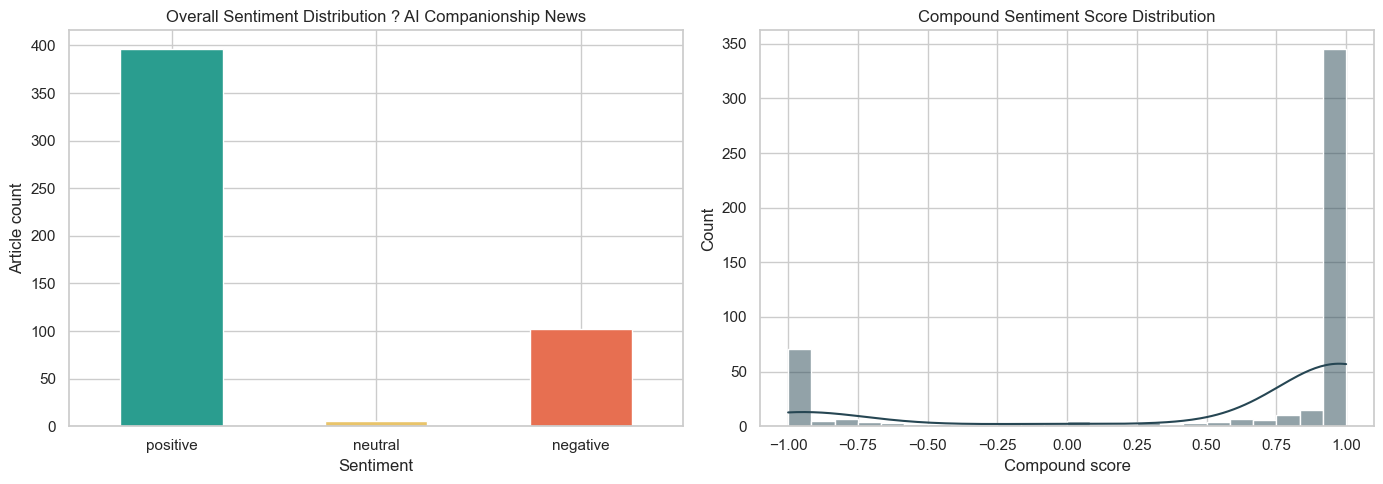

Overall sentiment (%):
sentiment_label
positive    78.73
negative    20.28
neutral      0.99
Name: proportion, dtype: float64
Total Unique News:  503


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Overall sentiment distribution ---
order = ['positive', 'neutral', 'negative']
colors = ['#2A9D8F', '#E9C46A', '#E76F51']
sentiment_df['sentiment_label'].value_counts().reindex(order).plot(
    kind='bar', color=colors, ax=axes[0]
)
axes[0].set_title('Overall Sentiment Distribution ? AI Companionship News')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Article count')
axes[0].tick_params(axis='x', rotation=0)

# --- Histogram: compound scores ---
sns.histplot(sentiment_df['compound'], bins=24, kde=True, color='#264653', ax=axes[1])
axes[1].set_title('Compound Sentiment Score Distribution')
axes[1].set_xlabel('Compound score')

plt.tight_layout()
plt.show()

overall_sentiment = sentiment_df['sentiment_label'].value_counts(normalize=True).mul(100).round(2)
print('Overall sentiment (%):')
print(overall_sentiment)
print('Total Unique News: ' , sentiment_df['sentiment_label'].value_counts().sum())

### Step 11 - Identify the Most Active Publisher Domains

**Objective:** Quantify which source domains contribute the most articles to the strict corpus.

**Rationale:** Source concentration matters for interpretation. A corpus dominated by a small number of publishers may reflect editorial clustering rather than a broad media consensus, so domain distribution is an important context layer for every downstream insight.

**How to review this cell:** Look for dominant publishers and consider whether the source mix is sufficiently diverse for the claims you want to make in the final report.

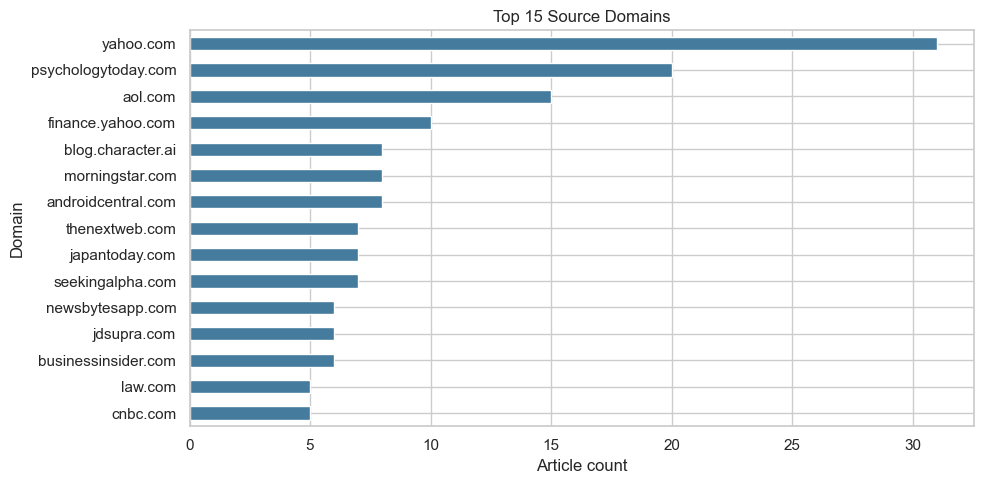

In [12]:
# --- Top source domains ---
if 'domain' in sentiment_df.columns:
    top_domains = sentiment_df['domain'].value_counts().head(15)
    top_domains.plot(kind='barh', figsize=(10, 5), color='#457B9D')
    plt.title('Top 15 Source Domains')
    plt.xlabel('Article count')
    plt.ylabel('Domain')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

### Step 12 - Centralise Artifact Filenames

**Objective:** Define the canonical filenames used for the notebook's exported analysis artefacts.

**Rationale:** Keeping output names in one place reduces operational mistakes and makes the notebook easier to maintain. It also documents, in one short block, which deliverables the workflow is expected to produce.

**How to review this cell:** Confirm the filenames align with the strict-analysis naming convention and match the CSVs and JSON files expected by downstream consumers.

In [13]:
OUTPUT_JSON              = 'ai_companionship_news_strict.json'
OUTPUT_CSV               = 'ai_companionship_news_strict.csv'
OUTPUT_SENTIMENT_CSV     = 'ai_companionship_news_sentiment_strict.csv'
FAILED_OUTPUT_CSV        = 'ai_companionship_news_failed_strict.csv'
DISCOVERY_LOG_CSV        = 'ai_companionship_discovery_log_strict.csv'
TERM_FREQ_CSV            = 'ai_companionship_term_frequency_strict.csv'
LDA_MODEL_SCORES_CSV     = 'ai_companionship_lda_k4_k8_scores_strict.csv'
LDA_TOPIC_TERMS_CSV      = 'ai_companionship_lda_topic_terms_strict.csv'
SNA_CENTRALITY_CSV       = 'ai_companionship_network_centrality_strict.csv'

### Step 13 - Compare Sentiment by Search Query

**Objective:** Break sentiment outcomes down by the highest-volume search queries that generated the articles.

**Rationale:** Query-level analysis helps separate media sentiment from collection bias. If certain queries systematically surface more negative or more positive stories, that influences how the corpus should be interpreted and how future crawl strategies should be designed.

**How to review this cell:** Inspect the stacked bar chart for query-level imbalances and use the exported summary CSV as a structured table for appendices, dashboards, or further statistical testing.

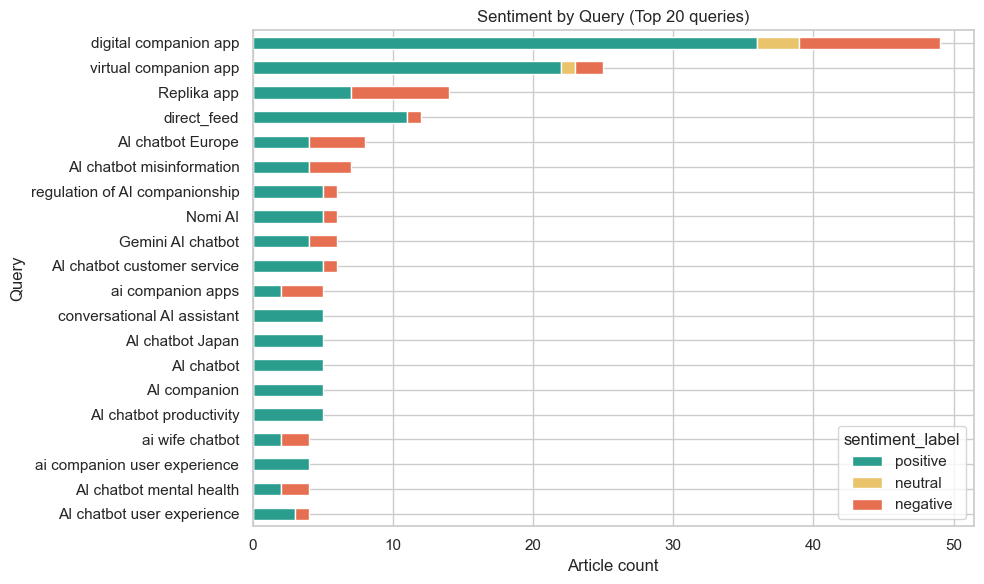

Saved sentiment summary to summary_ai_companionship_news_strict.csv


In [14]:
# --- Sentiment by query (top queries only) ---
summary_df = (
    sentiment_df
    .groupby(['query', 'sentiment_label'])
    .size()
    .reset_index(name='article_count')
    .sort_values(['query', 'article_count'], ascending=[True, False])
)

top_queries = sentiment_df['query'].value_counts().head(20).index.tolist()
top_summary = summary_df[summary_df['query'].isin(top_queries)]

if not top_summary.empty:
    pivot = top_summary.pivot_table(
        index='query', columns='sentiment_label', values='article_count', fill_value=0
    )
    for col in ['positive', 'neutral', 'negative']:
        if col not in pivot.columns:
            pivot[col] = 0
    pivot['total'] = pivot.sum(axis=1)
    pivot = pivot.sort_values('total', ascending=True).drop(columns='total')
    pivot[['positive', 'neutral', 'negative']].plot(
        kind='barh', stacked=True, figsize=(10, 6),
        color=['#2A9D8F', '#E9C46A', '#E76F51']
    )
    plt.title('Sentiment by Query (Top 20 queries)')
    plt.xlabel('Article count')
    plt.ylabel('Query')
    plt.tight_layout()
    plt.show()

summary_df.to_csv('summary_ai_companionship_news_strict.csv', index=False)
print('Saved sentiment summary to summary_ai_companionship_news_strict.csv')



### Step 14 - Compare Sentiment by Publisher Domain

**Objective:** Measure sentiment distributions across the highest-volume publication domains.

**Rationale:** Domain-level sentiment helps identify whether certain outlets frame AI companionship in a consistently optimistic, neutral, or risk-oriented way. This is useful for editorial analysis and for detecting source-specific narrative bias.

**How to review this cell:** Focus on domains with meaningful article volume. Strong deviations from the overall baseline may indicate editorial positioning or niche audience targeting.

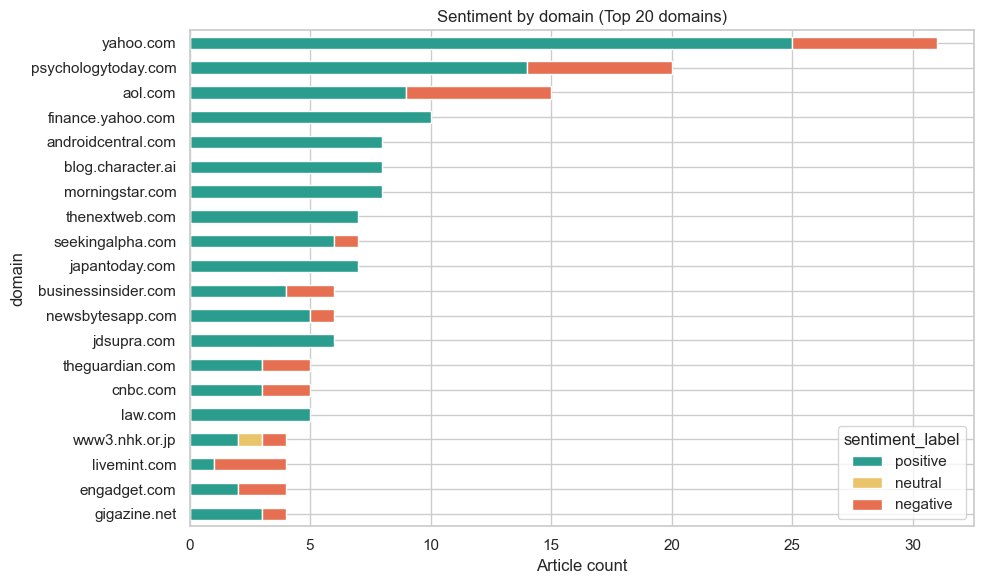

In [15]:
# --- Sentiment by domain (top domains only) ---
summary_df = (
    sentiment_df
    .groupby(['domain', 'sentiment_label'])
    .size()
    .reset_index(name='article_count')
    .sort_values(['domain', 'article_count'], ascending=[True, False])
)

top_domains = sentiment_df['domain'].value_counts().head(20).index.tolist()
top_summary = summary_df[summary_df['domain'].isin(top_domains)]

if not top_summary.empty:
    pivot = top_summary.pivot_table(
        index='domain', columns='sentiment_label', values='article_count', fill_value=0
    )
    for col in ['positive', 'neutral', 'negative']:
        if col not in pivot.columns:
            pivot[col] = 0
    pivot['total'] = pivot.sum(axis=1)
    pivot = pivot.sort_values('total', ascending=True).drop(columns='total')
    pivot[['positive', 'neutral', 'negative']].plot(
        kind='barh', stacked=True, figsize=(10, 6),
        color=['#2A9D8F', '#E9C46A', '#E76F51']
    )
    plt.title('Sentiment by domain (Top 20 domains)')
    plt.xlabel('Article count')
    plt.ylabel('domain')
    plt.tight_layout()
    plt.show()

### Step 15 - Compare Sentiment by Discovery Channel

**Objective:** Examine whether sentiment profiles differ by `discovery_source`.

**Rationale:** Different discovery mechanisms can surface different slices of the information environment. Comparing them helps determine whether the observed sentiment distribution is stable across collection methods or shaped by one intake channel.

**How to review this cell:** Compare the discovery-source chart with the prior query and domain views. Converging patterns increase confidence, while sharp differences suggest collection-method effects that should be documented.

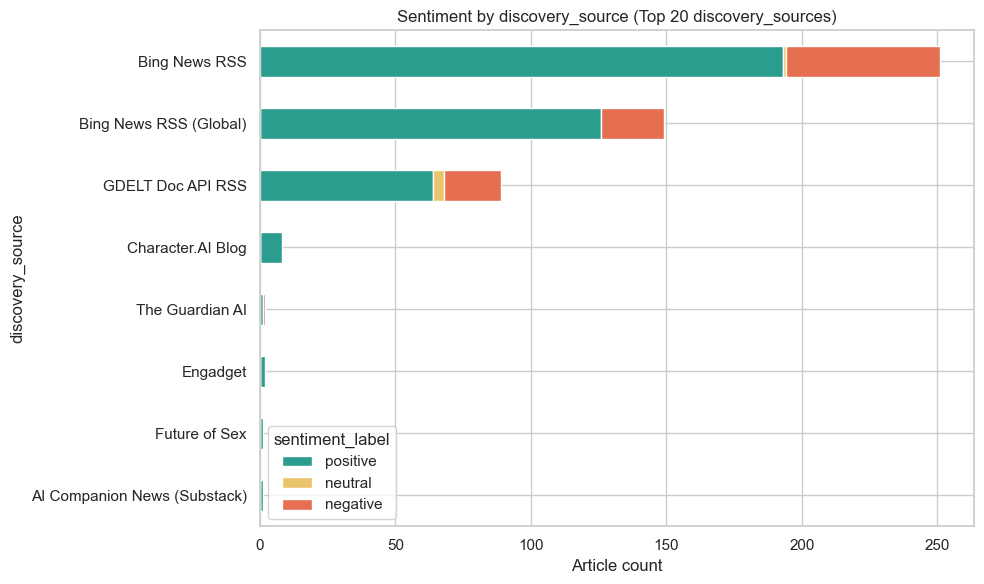

In [16]:
# --- Sentiment by discovery_source (top discovery_sources only) ---
summary_df = (
    sentiment_df
    .groupby(['discovery_source', 'sentiment_label'])
    .size()
    .reset_index(name='article_count')
    .sort_values(['discovery_source', 'article_count'], ascending=[True, False])
)

top_discovery_sources = sentiment_df['discovery_source'].value_counts().head(20).index.tolist()
top_summary = summary_df[summary_df['discovery_source'].isin(top_discovery_sources)]

if not top_summary.empty:
    pivot = top_summary.pivot_table(
        index='discovery_source', columns='sentiment_label', values='article_count', fill_value=0
    )
    for col in ['positive', 'neutral', 'negative']:
        if col not in pivot.columns:
            pivot[col] = 0
    pivot['total'] = pivot.sum(axis=1)
    pivot = pivot.sort_values('total', ascending=True).drop(columns='total')
    pivot[['positive', 'neutral', 'negative']].plot(
        kind='barh', stacked=True, figsize=(10, 6),
        color=['#2A9D8F', '#E9C46A', '#E76F51']
    )
    plt.title('Sentiment by discovery_source (Top 20 discovery_sources)')
    plt.xlabel('Article count')
    plt.ylabel('discovery_source')
    plt.tight_layout()
    plt.show()

### Step 16 - Define Vocabulary Diagnostic Helpers for Topic Modelling

**Objective:** Create reusable functions that detect low-value words and cross-topic generic vocabulary before topic refinement.

**Rationale:** Topic quality often depends less on the modelling algorithm than on vocabulary discipline. These helpers provide a systematic way to identify terms that appear everywhere, contribute little discrimination, or dilute topic clarity.

**How to review this cell:** Treat it as methodology infrastructure. The functions are not the result themselves; they are diagnostic tools used later to improve interpretability.

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

def extract_topic_useless_words(lda_model, feature_names, threshold=0.9):
    import numpy as np

    topic_word_dist = lda_model.components_ / lda_model.components_.sum(axis=1)[:, None]

    # words that appear strongly across many topics
    word_topic_presence = (topic_word_dist > (1 / len(feature_names))).sum(axis=0)

    useless_words = [
        feature_names[i]
        for i in range(len(feature_names))
        if word_topic_presence[i] / lda_model.n_components > threshold
    ]

    return set(useless_words)




def get_low_tfidf_words(docs, threshold=0.1):
    tfidf = TfidfVectorizer(
        lowercase=True,
        token_pattern=r"[a-z]{3,}"
    )

    X = tfidf.fit_transform(docs)
    terms = np.array(tfidf.get_feature_names_out())

    avg_tfidf = X.mean(axis=0).A1

    low_value_terms = terms[avg_tfidf < threshold]

    return set(low_value_terms)

### Step 17 - Build the Custom Stopword Strategy

**Objective:** Assemble the domain-specific stopword policy used by term-frequency analysis, topic modelling, and network construction.

**Rationale:** Generic English stopwords are not enough for a news corpus. This custom list removes newsroom filler, hardware-review noise, web artefacts, and research-index vocabulary while intentionally preserving anchor terms such as `ai` and `chatbot` that define the business domain.

**How to review this cell:** Check the total stopword count and review the curated categories. The commented auto-stopword logic can be reactivated if the corpus changes substantially, but the current list acts as the primary editorial vocabulary policy for the notebook.

In [18]:
from sklearn.feature_extraction.text import CountVectorizer

import numpy as np

def generate_auto_stopwords(docs, 
                           max_df=0.85,     # appears in >85% docs
                           min_df=5,        # ignore rare noise
                           top_n_freq=50):  # most frequent words

    vectorizer = CountVectorizer(
        lowercase=True,
        token_pattern=r"[a-z]{3,}",
        min_df=min_df,
        max_df=max_df
    )

    X = vectorizer.fit_transform(docs)
    terms = np.array(vectorizer.get_feature_names_out())

    # --- 1. HIGH DOCUMENT FREQUENCY (global noise) ---
    doc_freq = (X > 0).sum(axis=0).A1
    doc_freq_ratio = doc_freq / X.shape[0]

    high_df_terms = terms[doc_freq_ratio > max_df]

    # --- 2. TOP FREQUENCY TERMS ---
    term_freq = X.sum(axis=0).A1
    top_freq_terms = terms[np.argsort(term_freq)[-top_n_freq:]]

    auto_stopwords = set(high_df_terms).union(set(top_freq_terms))

    return auto_stopwords

# ---------------------------------------------------------------------------
# WORD FREQUENCY + WORD CLOUD
# ---------------------------------------------------------------------------
custom_stopwords = set(ENGLISH_STOP_WORDS).union({

    # news filler
    'said','says','also','would','could','new','news','report','reports','media','instead',
    'according','reported','report','reports','told','including','based','just','best',

    # ❗ KEEP domain anchors (IMPORTANT)
    'ai','chatbot', 

    # generic
    'user','users','people','company','companies','platform','use',
    'person','individual','individuals','world','life','way',

    # generic verbs
    'make','using','used','use','want','need','know','think','going',
    'get','take','come','look','see','say','makes','making','does','did',

    # verbs
    'make','using','used','want','need','know','think','going',
    'get','take','come','look','see','say','makes','making','does','did',

    # time
    'time','year','years','month','months','day','days','today','recent',
    'january','february','march','april','may','june','july','august','september','october','november','december',

    # weak words (VERY IMPORTANT)
    'thing','things','something','anything','everything',
    'way','ways','kind','sort','lot','lots',
    'example','case','part','parts','type','types',

    # tech noise
    'data','system','systems','model','models','platform','platforms',
    'technology','tech','tools','service','services','software','hardware',
    'dm','remove','convert','display','check','branch','enable','test','drop','pm', 

    # gadget noise (CRITICAL)
    'watch','smartwatch','earbuds','headphones',
    'camera','lens','sensor','display','screen','battery',
    'chip','processor','gpu','cpu','benchmark','performance',
    'qualcomm','snapdragon','exynos','mediatek',
    'launch','released','release','announced','pricing','price',

    # hardware noise
    'arm','amd','intel','usb','driver','drivers','wifi',
    'android','node','register','clock','buffer','tokens','token','core','phy','snd',
    'drm', 'git', 'kernel','linux','merge',

    # web artifacts
    'https','www','com','org','net','ref','tag','pub','error',

    # years
    '2023','2024','2025','2026',

    # companies (REMOVE noisy ones only)
    'apple','google','microsoft','meta','amazon','samsung','nvidia','tesla',

    'et','la','di','il','19','der','soc','update','ve','und','pro','don',
    'che','le','una','non','del','si','ha','da','al','ma','000','die','ist',
    'sie','das','den','dan','mit','eine','von','zu','fur','en','ein',    

    'arxiv','arxivlabs','ll'

    'its', 'was', 'one', 'are', 'time', 'but', 'these', 'than', 'not','like', 'apps',
    'more', 'can', 'you', 'what', 'while', 'all', 'digital','market','week','day','free','app',

    'paper','research','outcome','papers','journal','bibliographic','citation',
    'cite','reference','code','sciencecast','litmap','collaborator','publish','published',
    'dagshub','catalyzex','alphaxiv','explorer','collaborators','authors','author',
    'researcher','values','value','smart','content','community','features','view',
    'tools','tool','connected','litmaps','website','allows','search','citations',
    'work','experimental','experiment','computer','share','pc','article','face','learn',



})

#docs = (sentiment_df['title'].fillna('') + ' ' + sentiment_df['text'].fillna('')).tolist()

#auto_stopwords = generate_auto_stopwords(docs)

#print("Auto detected stopwords:", list(auto_stopwords)[:100])

# Merge with your existing ones
#custom_stopwords = custom_stopwords.union(auto_stopwords)


print(f"Total stopwords: {len(custom_stopwords)}")

Total stopwords: 577


### Step 18 - Generate Term Frequencies and Word Cloud

**Objective:** Tokenise the strict corpus with the curated stopword policy, normalise major company names, and export headline lexical features.

**Rationale:** This cell provides the first interpretable view of what the corpus is actually talking about. Replacing company names with `tech_company` reduces brand dominance, while the frequency table and word cloud make recurring themes visible before topic modelling.

**How to review this cell:** Verify that the saved term-frequency CSV contains semantically meaningful terms and that the highest-frequency words reflect genuine themes rather than boilerplate or publisher artefacts.

Saved term frequencies to ai_companionship_term_frequency_strict.csv


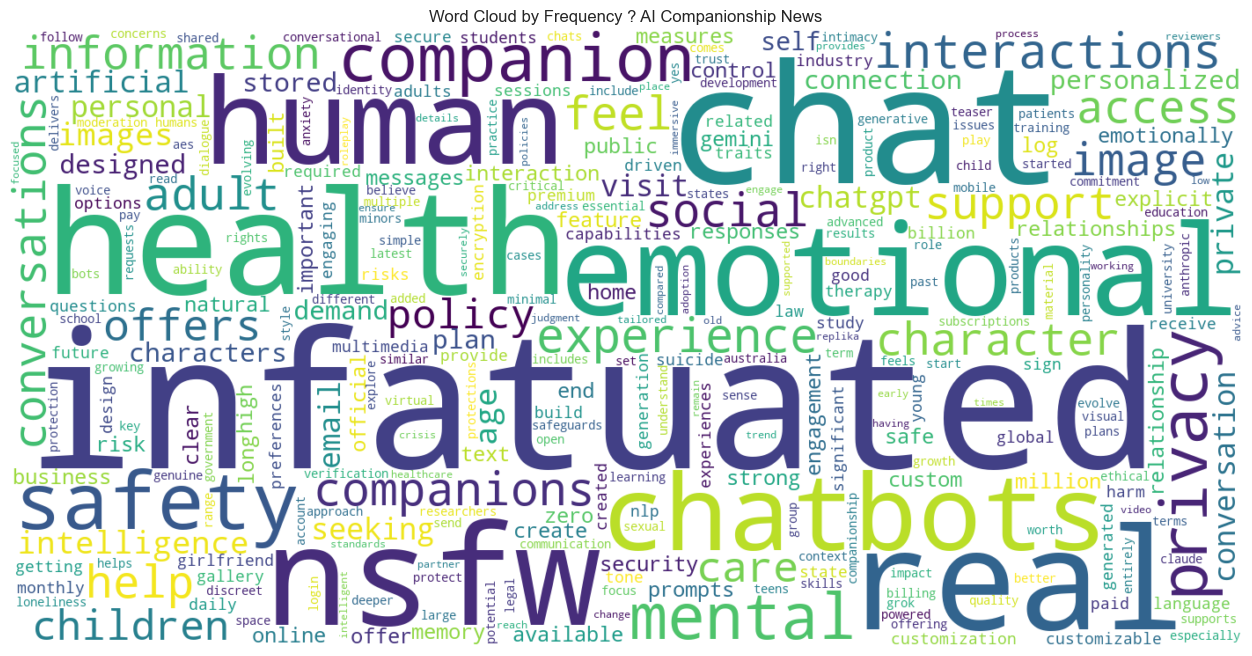

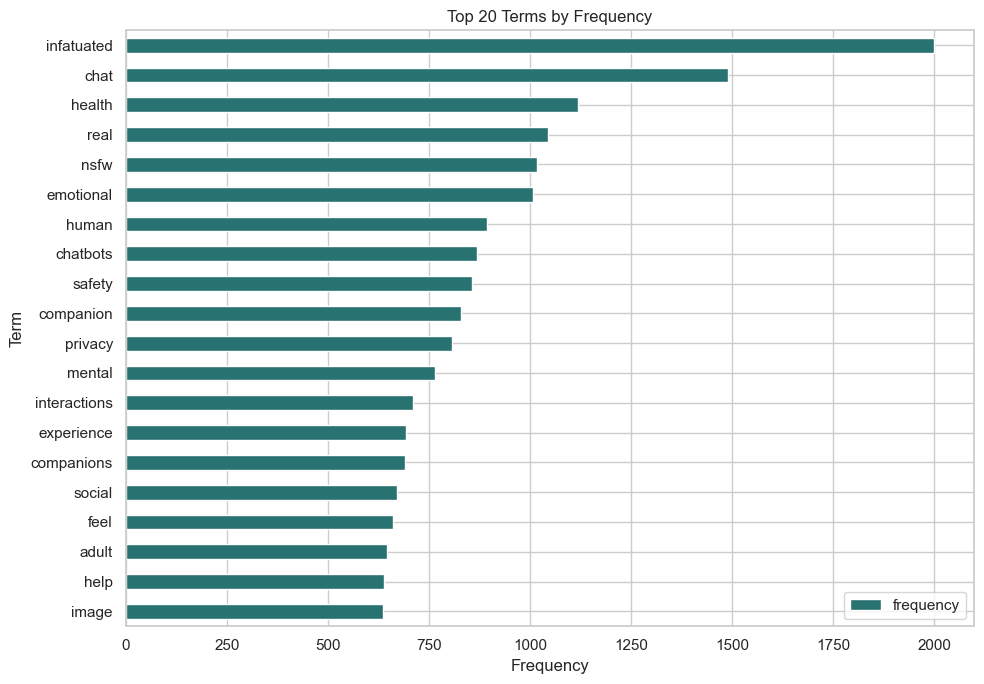

In [19]:
def tokenize_for_analysis(text: str) -> list[str]:
    tokens = re.findall(r"[a-z]{3,}", (text or '').lower())
    return [t for t in tokens if t not in custom_stopwords]

COMPANY_PATTERN = re.compile(
    r'\b(apple|google|microsoft|openai|meta|amazon|samsung|linux|nvidia|tesla|xai)\b',
    flags=re.IGNORECASE
)

def normalize_companies(text):
    return COMPANY_PATTERN.sub('tech_company', text)

analysis_text_series = sentiment_df['title'].fillna('') + ' ' + sentiment_df['text'].fillna('').apply(normalize_companies)
all_tokens = []
for txt in analysis_text_series:
    all_tokens.extend(tokenize_for_analysis(txt))


term_freq = Counter(all_tokens)
term_freq_df = pd.DataFrame(term_freq.items(), columns=['term', 'frequency']).sort_values(
    'frequency', ascending=False
)
term_freq_df.to_csv(TERM_FREQ_CSV, index=False, encoding='utf-8-sig')
print(f'Saved term frequencies to {TERM_FREQ_CSV}')

wc = WordCloud(
    width=1400,
    height=700,
    background_color='white',
    max_words=300,
    colormap='viridis'
).generate_from_frequencies(term_freq)

plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud by Frequency ? AI Companionship News')
plt.show()

term_freq_df.head(20).plot(kind='barh', x='term', y='frequency', figsize=(10, 7), color='#287271')
plt.gca().invert_yaxis()
plt.title('Top 20 Terms by Frequency')
plt.xlabel('Frequency')
plt.ylabel('Term')
plt.tight_layout()
plt.show()

### Step 19 - Train and Evaluate Candidate LDA Topic Models

**Objective:** Build document-term matrices, fit LDA models for `K=4..8`, compare them using perplexity and topic diversity, and export the model-selection artefacts.

**Rationale:** A professional topic-modelling workflow should not choose the number of topics arbitrarily. This cell balances statistical fit with interpretability by ranking candidate models on both lower perplexity and higher topic diversity, then selecting a best `K` for downstream reporting.

**How to review this cell:** Read the model score table first, then inspect the top-term charts for each `K`. The chosen `best_k` should be both numerically defensible and substantively interpretable.

Best K by combined rank: 6


,k,perplexity,topic_diversity,perplexity_rank,diversity_rank,combined_rank
0,6,1479.115844,0.819444,3.0,2.0,5.0
1,8,1411.273842,0.802083,1.0,4.0,5.0
2,5,1535.773522,0.833333,5.0,1.0,6.0
3,4,1531.271512,0.812500,4.0,3.0,7.0
4,7,1419.243096,0.761905,2.0,5.0,7.0


Saved LDA model scores to ai_companionship_lda_k4_k8_scores_strict.csv
Saved LDA topic terms to ai_companionship_lda_topic_terms_strict.csv


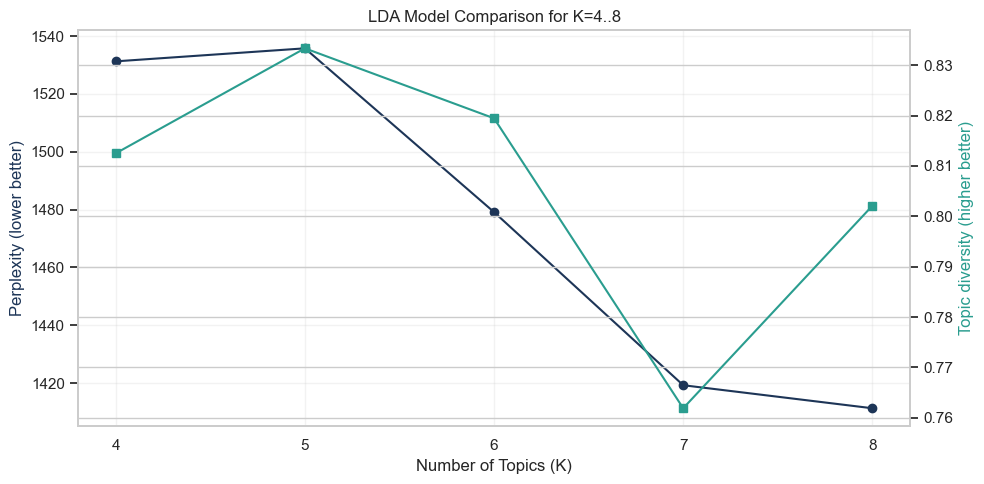

LDA topic chart for K=4


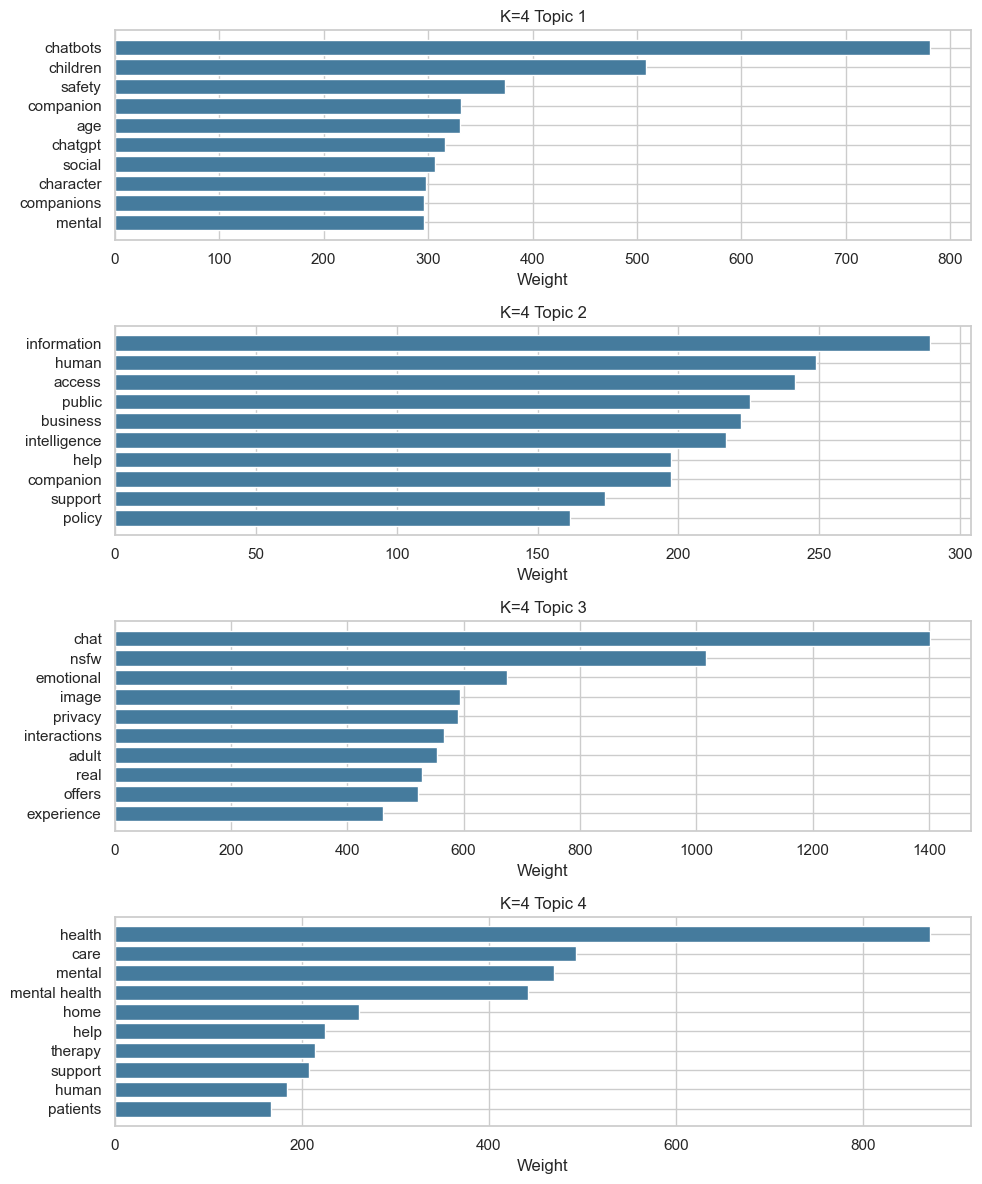

LDA topic chart for K=5


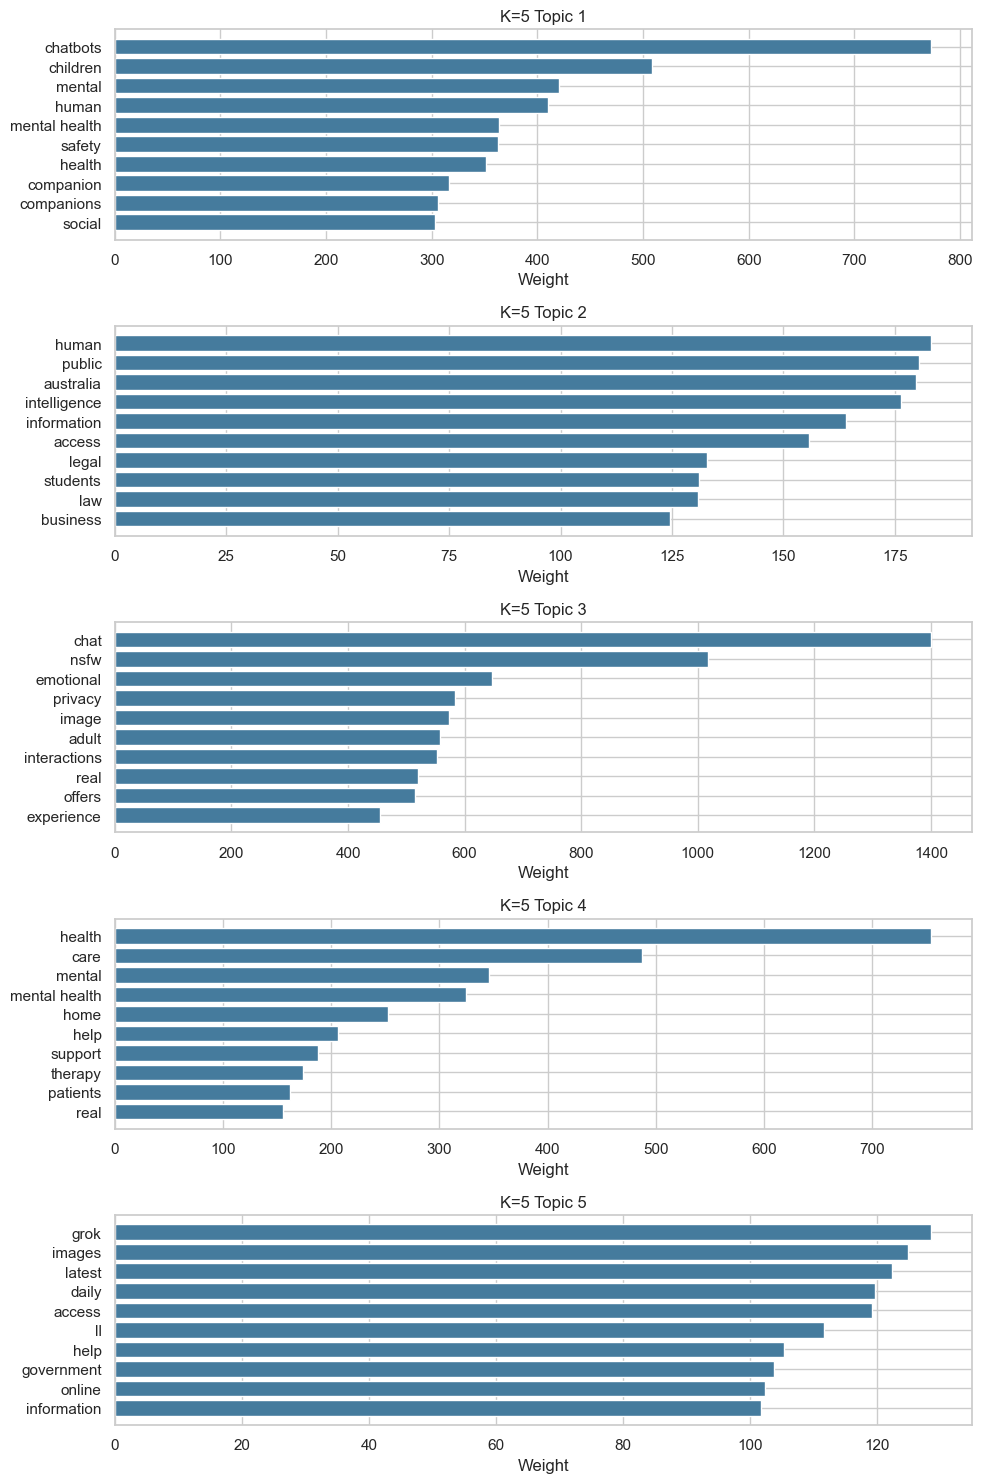

LDA topic chart for K=6


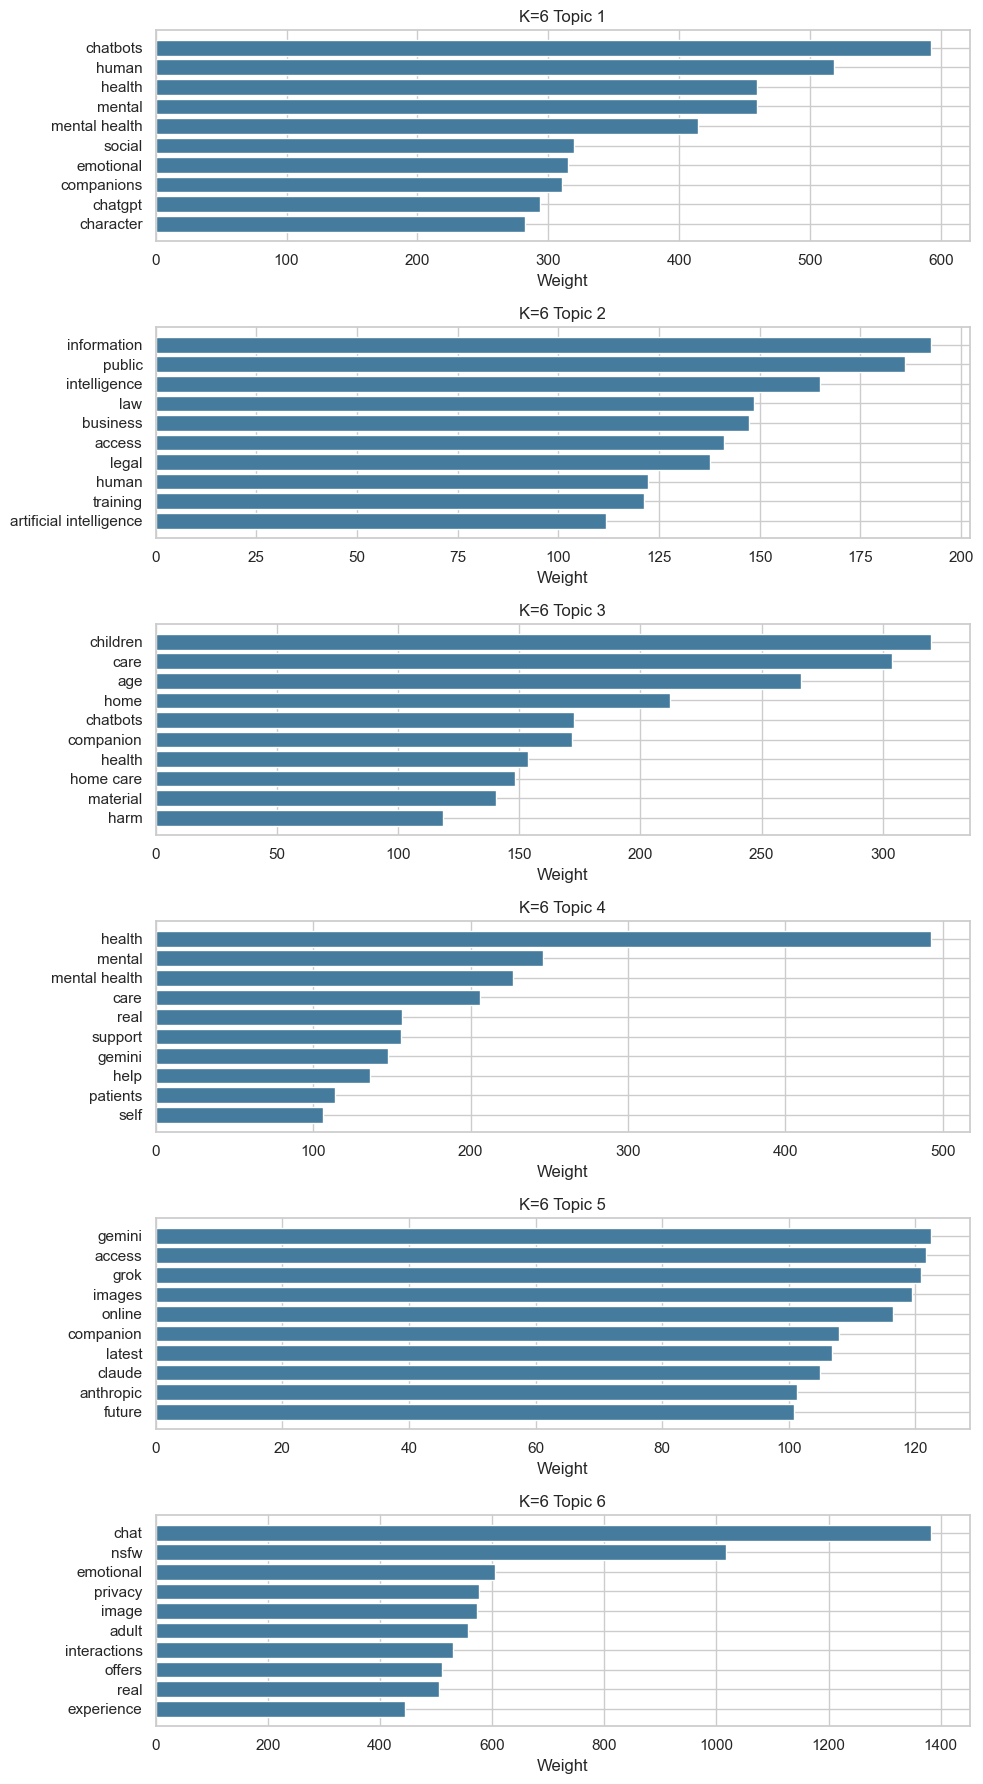

LDA topic chart for K=7


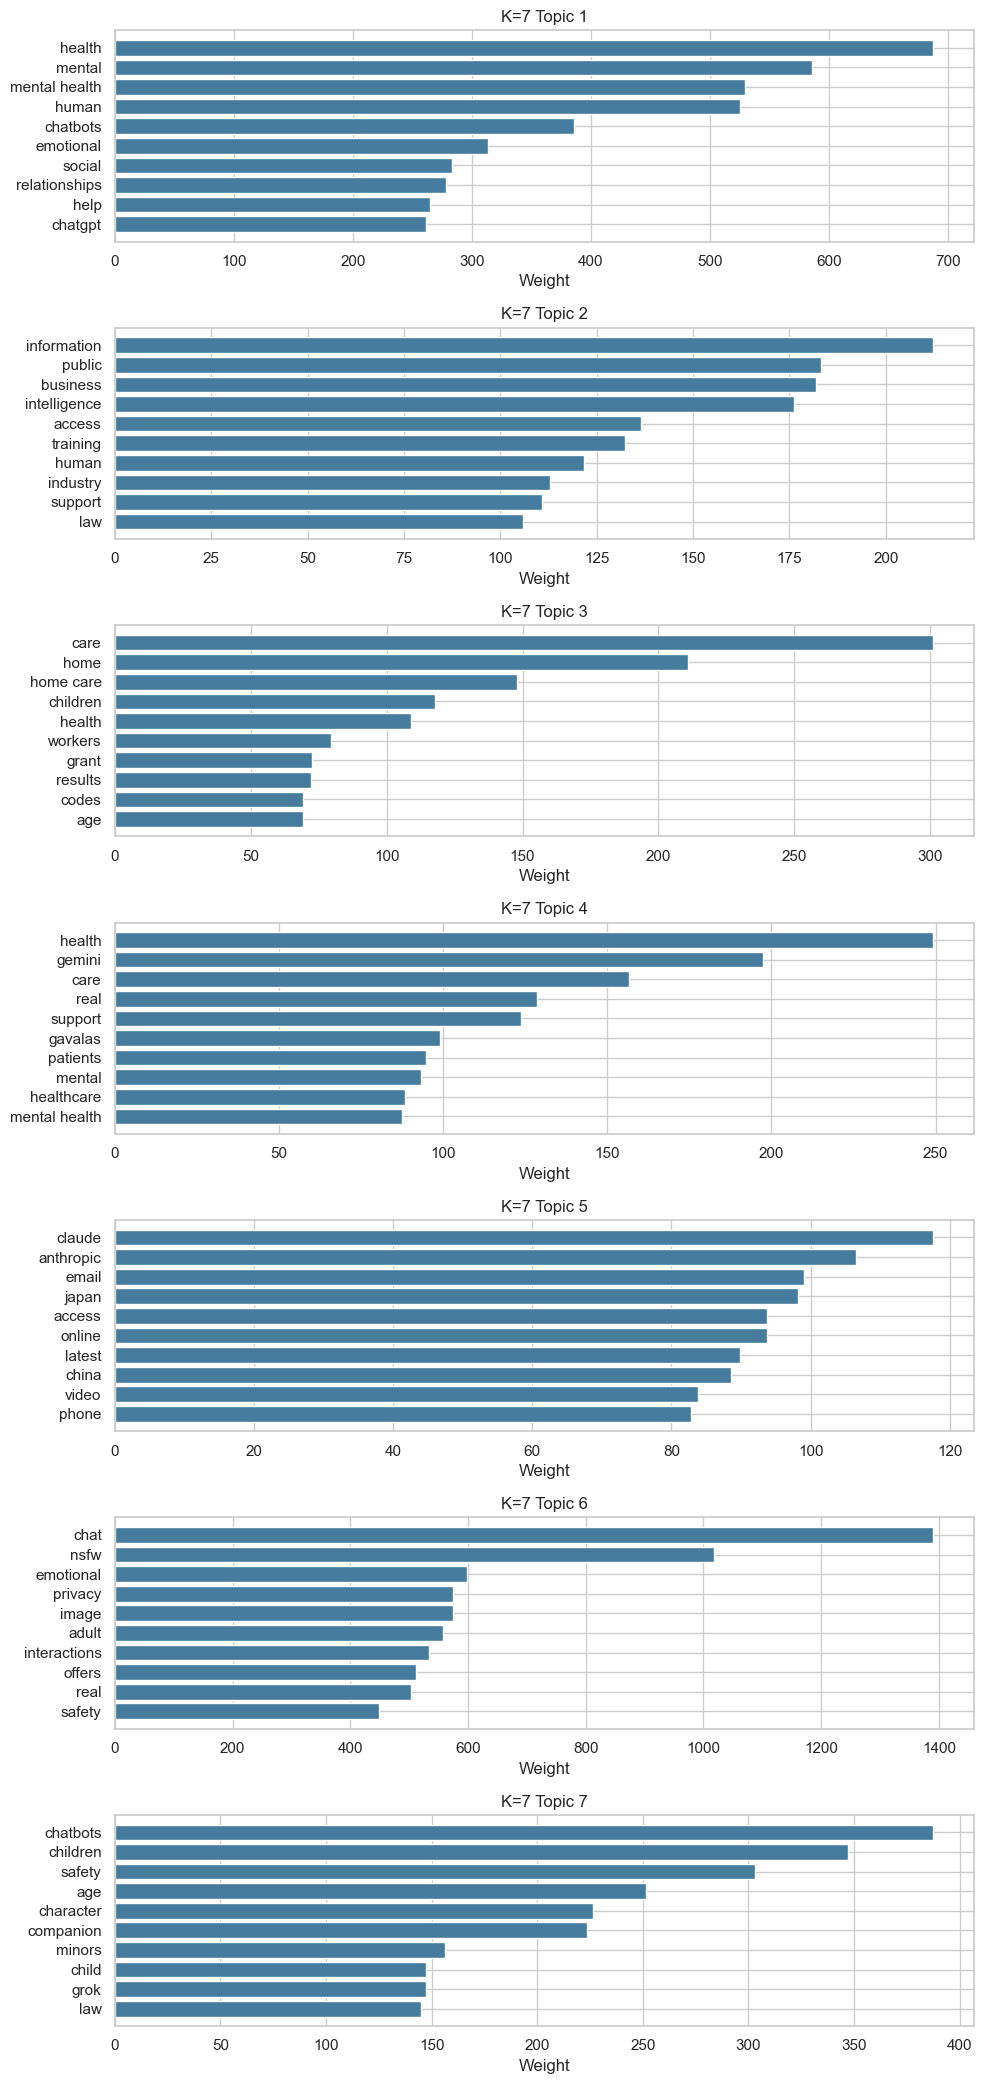

LDA topic chart for K=8


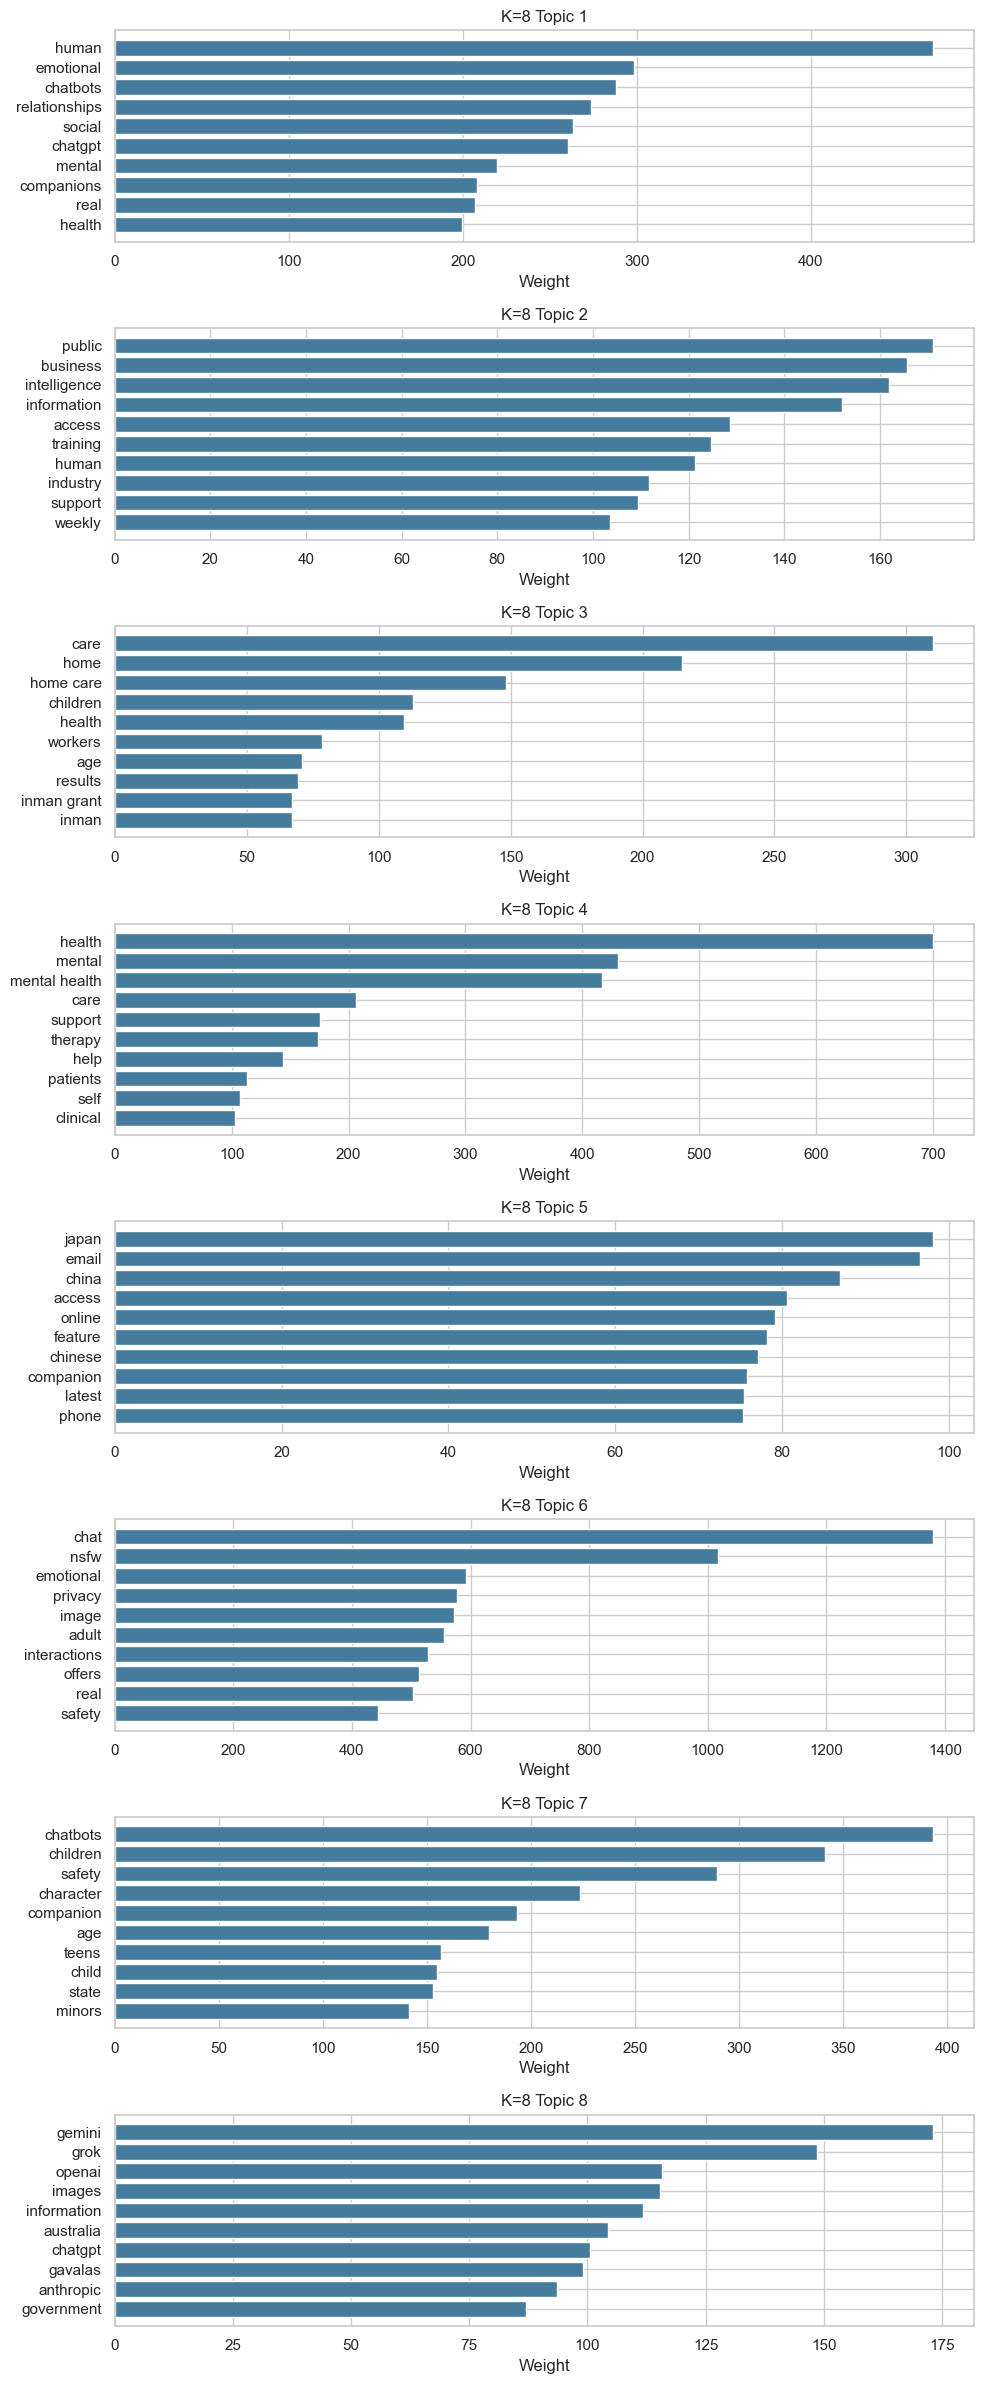

In [108]:
# ---------------------------------------------------------------------------
# LDA TOPIC MODELLING ? K = 4..8 (comparison + charts)
# ---------------------------------------------------------------------------
docs = (sentiment_df['title'].fillna('') + ' ' + sentiment_df['text'].fillna('')).tolist()
vectorizer = CountVectorizer(
    lowercase=True,
    stop_words=list(custom_stopwords),
    min_df=5,
    max_df=0.9,
    max_features=4000,
    ngram_range=(1, 2)
)

dtm = vectorizer.fit_transform(docs)
feature_names = vectorizer.get_feature_names_out()

model_scores = []
models_by_k = {}
all_topic_terms_rows = []

for k in range(4, 9):
    lda = LatentDirichletAllocation(
        n_components=k,
        random_state=42,
        learning_method='batch',
        max_iter=25,
        n_jobs=-1,
    )
    lda.fit(dtm)
    perplexity = lda.perplexity(dtm)

    top_n = 12
    top_terms = []
    for topic_idx, topic_weights in enumerate(lda.components_):
        term_idx = topic_weights.argsort()[-top_n:][::-1]
        terms = [feature_names[i] for i in term_idx]
        top_terms.append(terms)
        for rank, term in enumerate(terms, start=1):
            all_topic_terms_rows.append({
                'k': k,
                'topic_id': topic_idx,
                'rank': rank,
                'term': term,
                'weight': float(topic_weights[term_idx[rank - 1]])
            })

    unique_top_terms = len(set(term for terms in top_terms for term in terms))
    topic_diversity = unique_top_terms / (k * top_n)

    model_scores.append({
        'k': k,
        'perplexity': float(perplexity),
        'topic_diversity': float(topic_diversity),
    })
    models_by_k[k] = lda

model_scores_df = pd.DataFrame(model_scores)
model_scores_df['perplexity_rank'] = model_scores_df['perplexity'].rank(method='min')
model_scores_df['diversity_rank'] = model_scores_df['topic_diversity'].rank(ascending=False, method='min')
model_scores_df['combined_rank'] = model_scores_df['perplexity_rank'] + model_scores_df['diversity_rank']
model_scores_df = model_scores_df.sort_values('combined_rank').reset_index(drop=True)

best_k = int(model_scores_df.iloc[0]['k'])
print(f'Best K by combined rank: {best_k}')
display(model_scores_df)

model_scores_df.to_csv(LDA_MODEL_SCORES_CSV, index=False, encoding='utf-8-sig')
pd.DataFrame(all_topic_terms_rows).to_csv(LDA_TOPIC_TERMS_CSV, index=False, encoding='utf-8-sig')
print(f'Saved LDA model scores to {LDA_MODEL_SCORES_CSV}')
print(f'Saved LDA topic terms to {LDA_TOPIC_TERMS_CSV}')

plot_scores_df = model_scores_df.sort_values('k')
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(plot_scores_df['k'], plot_scores_df['perplexity'], marker='o', color='#1D3557')
ax2.plot(plot_scores_df['k'], plot_scores_df['topic_diversity'], marker='s', color='#2A9D8F')

ax1.set_xlabel('Number of Topics (K)')
ax1.set_ylabel('Perplexity (lower better)', color='#1D3557')
ax2.set_ylabel('Topic diversity (higher better)', color='#2A9D8F')
ax1.set_title('LDA Model Comparison for K=4..8')
ax1.set_xticks(range(4, 9))
ax1.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# LDA topic charts for each K (4..8)
def plot_topics_for_k(lda_model, k: int, n_terms: int = 10):
    rows = k
    fig, axes = plt.subplots(rows, 1, figsize=(10, max(3 * rows, 8)))
    if rows == 1:
        axes = [axes]

    for topic_idx, ax in enumerate(axes):
        topic_weights = lda_model.components_[topic_idx]
        top_idx = topic_weights.argsort()[-n_terms:][::-1]
        top_terms = [feature_names[i] for i in top_idx][::-1]
        top_vals = topic_weights[top_idx][::-1]

        ax.barh(top_terms, top_vals, color='#457B9D')
        ax.set_title(f'K={k} Topic {topic_idx + 1}')
        ax.set_xlabel('Weight')
    plt.tight_layout()
    plt.show()

for k in range(4, 9):
    print(f'LDA topic chart for K={k}')
    plot_topics_for_k(models_by_k[k], k, n_terms=10)



### Step 20 - Inspect Available Columns for Downstream Modelling

**Objective:** Display the dataframe schema before moving into network analysis and topic-level exports.

**Rationale:** Late-stage notebook sections often depend on derived columns such as `topic_relevant`, `quality_filter_reason`, and `analysis_text`. A schema check here prevents silent failures and makes the downstream assumptions visible.

**How to review this cell:** Confirm that the columns required by the network-analysis cells are present, especially if the notebook is being rerun on a regenerated or externally supplied CSV.

In [23]:
sentiment_df.columns

Index(['query', 'discovery_source', 'feed_title', 'feed_summary', 'url',
       'original_feed_url', 'published_at', 'source_hint', 'final_url',
       'domain', 'title', 'text', 'authors', 'article_publish_date',
       'top_image', 'status', 'error', 'scraped_at', 'content_length', 'neg',
       'neu', 'pos', 'compound', 'sentiment_label', 'dataset', 'source_file',
       'topic_relevant', 'quality_filter_reason', 'topic_anchor_hits',
       'bad_pattern_hits', 'token_count', 'unique_token_ratio',
       'japan_relevant', 'US_relevant', 'detected_language',
       'was_translated_to_english', 'original_query', 'original_title',
       'original_text', 'clean_title', 'clean_text', 'analysis_text',
       'analysis_length', 'url_key', 'title_key', 'text_key',
       'removal_reason'],
      dtype='object')

### Step 21 - Build a Domain Similarity Network

**Objective:** Aggregate article text by domain, vectorise it with TF-IDF, and create a network where edges represent vocabulary similarity between publishers.

**Rationale:** This cell offers a publisher-level structural view that complements sentiment and topic outputs. Instead of asking whether outlets are positive or negative, it asks which outlets talk about AI companionship using similar language and therefore occupy similar narrative space.

**How to review this cell:** Check the node and edge counts, then inspect the resulting communities. The similarity threshold is intentionally tunable; if the graph is too sparse or too dense, adjust it and document the final choice.

Number of unique domains with text: 159
TF‑IDF matrix shape: (159, 500)
Network nodes: 159, edges: 802
Top 20 domains by weighted degree:


,domain,weighted_degree
156,yahoo.com,29.244220
110,psychologytoday.com,18.701188
99,oregonlive.com,17.453180
38,cnbc.com,16.564944
11,aol.com,13.363734
149,us.cnn.com,11.083046
141,thehindu.com,10.398665
49,economictimes.indiatimes.com,10.359578
86,miragenews.com,10.105875
73,irishsun.com,10.047556


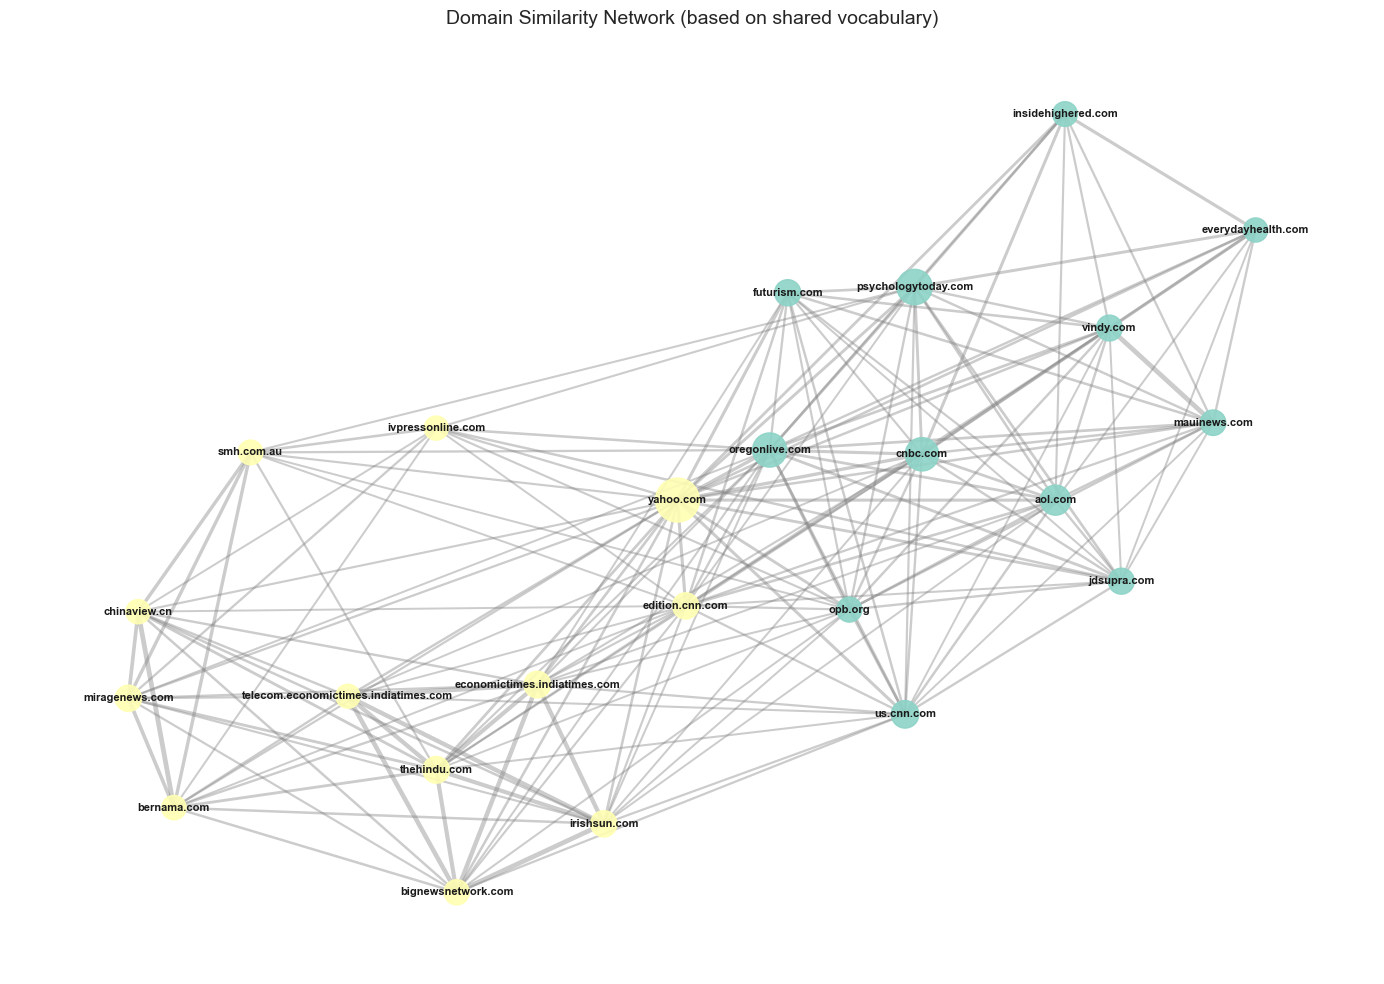

In [27]:
# ---------------------------------------------------------------------------
# DOMAIN SIMILARITY NETWORK ANALYSIS
# Replaces term co‑occurrence with domain‑level similarity
# ---------------------------------------------------------------------------

import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter

# -------------------------------
# 1. Aggregate text per domain
# -------------------------------
# Ensure we only use rows that passed quality filters and are topic relevant
valid_df = sentiment_df[sentiment_df['topic_relevant'] == True].copy()
valid_df = valid_df[valid_df['quality_filter_reason'].isna()]

# Concatenate all 'analysis_text' for each domain
domain_texts = valid_df.groupby('domain')['analysis_text'].apply(lambda texts: ' '.join(texts)).reset_index()
domain_texts = domain_texts[domain_texts['analysis_text'].str.strip() != '']

print(f"Number of unique domains with text: {len(domain_texts)}")

# -------------------------------
# 2. TF‑IDF vectorization
# -------------------------------
# Use a custom tokenizer if you want the same vocabulary control as before
vectorizer = TfidfVectorizer(
    max_features=500,       # keep top terms to avoid noise
    stop_words='english',
    min_df=2,               # term must appear in at least 2 domains
    max_df=0.8              # ignore overly common terms
)

tfidf_matrix = vectorizer.fit_transform(domain_texts['analysis_text'])
feature_names = vectorizer.get_feature_names_out()

print(f"TF‑IDF matrix shape: {tfidf_matrix.shape}")

# -------------------------------
# 3. Compute domain similarity
# -------------------------------
similarity_matrix = cosine_similarity(tfidf_matrix)

# -------------------------------
# 4. Build graph (similarity threshold)
# -------------------------------
G = nx.Graph()
domain_names = domain_texts['domain'].tolist()

# Add all domains as nodes (even isolated ones)
for domain in domain_names:
    G.add_node(domain)

# Add edges where similarity exceeds threshold
threshold = 0.3  # adjust as needed – higher = fewer edges

for i, domain_i in enumerate(domain_names):
    for j, domain_j in enumerate(domain_names):
        if i < j and similarity_matrix[i, j] >= threshold:
            G.add_edge(domain_i, domain_j, weight=similarity_matrix[i, j])

print(f'Network nodes: {G.number_of_nodes()}, edges: {G.number_of_edges()}')

# Remove isolated nodes for cleaner visualisation (optional)
# G = G.subgraph([n for n in G.nodes if G.degree(n) > 0]).copy()

# -------------------------------
# 5. Centrality (weighted degree)
# -------------------------------
if G.number_of_nodes() > 0:
    weighted_degree = dict(G.degree(weight='weight'))

    centrality_df = pd.DataFrame({
        'domain': list(G.nodes()),
        'weighted_degree': [weighted_degree[n] for n in G.nodes()],
    }).sort_values('weighted_degree', ascending=False)

    print("Top 20 domains by weighted degree:")
    display(centrality_df.head(20))

    # -------------------------------
    # 6. Focus on top domains (optional)
    # -------------------------------
    # Keep only the most connected domains for clarity
    top_n = 30
    top_domains = centrality_df.head(top_n)['domain'].tolist()
    subgraph = G.subgraph(top_domains).copy()

    # Keep largest connected component
    if nx.number_connected_components(subgraph) > 1:
        largest_cc = max(nx.connected_components(subgraph), key=len)
        subgraph = subgraph.subgraph(largest_cc).copy()

    if subgraph.number_of_nodes() == 0:
        print("Graph empty after filtering – lower the similarity threshold.")
    else:
        # -------------------------------
        # 7. Community detection
        # -------------------------------
        communities = list(nx.community.greedy_modularity_communities(subgraph))

        color_map = {}
        palette = plt.cm.Set3.colors

        for i, com in enumerate(communities):
            for node in com:
                color_map[node] = palette[i % len(palette)]

        node_colors = [color_map.get(n, "#cccccc") for n in subgraph.nodes()]

        # -------------------------------
        # 8. Layout
        # -------------------------------
        pos = nx.spring_layout(
            subgraph,
            k=2.5,
            iterations=200,
            seed=42
        )

        # -------------------------------
        # 9. Normalise node sizes by weighted degree
        # -------------------------------
        degrees = np.array([weighted_degree[n] for n in subgraph.nodes()])
        node_sizes = 300 + (degrees - degrees.min()) / (degrees.max() - degrees.min() + 1e-6) * 700

        # Edge widths proportional to similarity
        edge_weights = [subgraph[u][v]['weight'] for u, v in subgraph.edges()]
        edge_widths = 0.5 + np.array(edge_weights) * 3

        # -------------------------------
        # 10. Draw
        # -------------------------------
        plt.figure(figsize=(14, 10))

        nx.draw_networkx_nodes(
            subgraph,
            pos,
            node_size=node_sizes,
            node_color=node_colors,
            alpha=0.9
        )

        nx.draw_networkx_edges(
            subgraph,
            pos,
            width=edge_widths,
            edge_color='gray',
            alpha=0.4
        )

        # Label all nodes in subgraph (or top 15 only)
        nx.draw_networkx_labels(
            subgraph,
            pos,
            font_size=8,
            font_weight='bold'
        )

        plt.title("Domain Similarity Network (based on shared vocabulary)", fontsize=14)
        plt.axis('off')
        plt.tight_layout()
        plt.show()

else:
    print("Graph empty. Lower similarity threshold or include more domains.")

### Step 22 - Build the Reporting-Grade Term Co-occurrence Network

**Objective:** Construct a strict, readable term network from the most important vocabulary using window-based co-occurrence and strong edge filtering.

**Rationale:** This is the notebook's most presentation-ready lexical network view. By restricting the vocabulary and using a high minimum edge weight, it emphasises stable thematic relationships rather than every possible token association.

**How to review this cell:** Focus on whether the graph remains interpretable and whether the highest-weighted central terms align with the topic and frequency findings already established above.

SNA nodes: 60, edges: 1342


,term,weighted_degree
59,infatuated,11984
30,chat,8869
23,health,6438
50,nsfw,6064
20,real,6042
9,emotional,5911
29,human,5135
3,chatbots,4937
45,safety,4930
7,privacy,4701


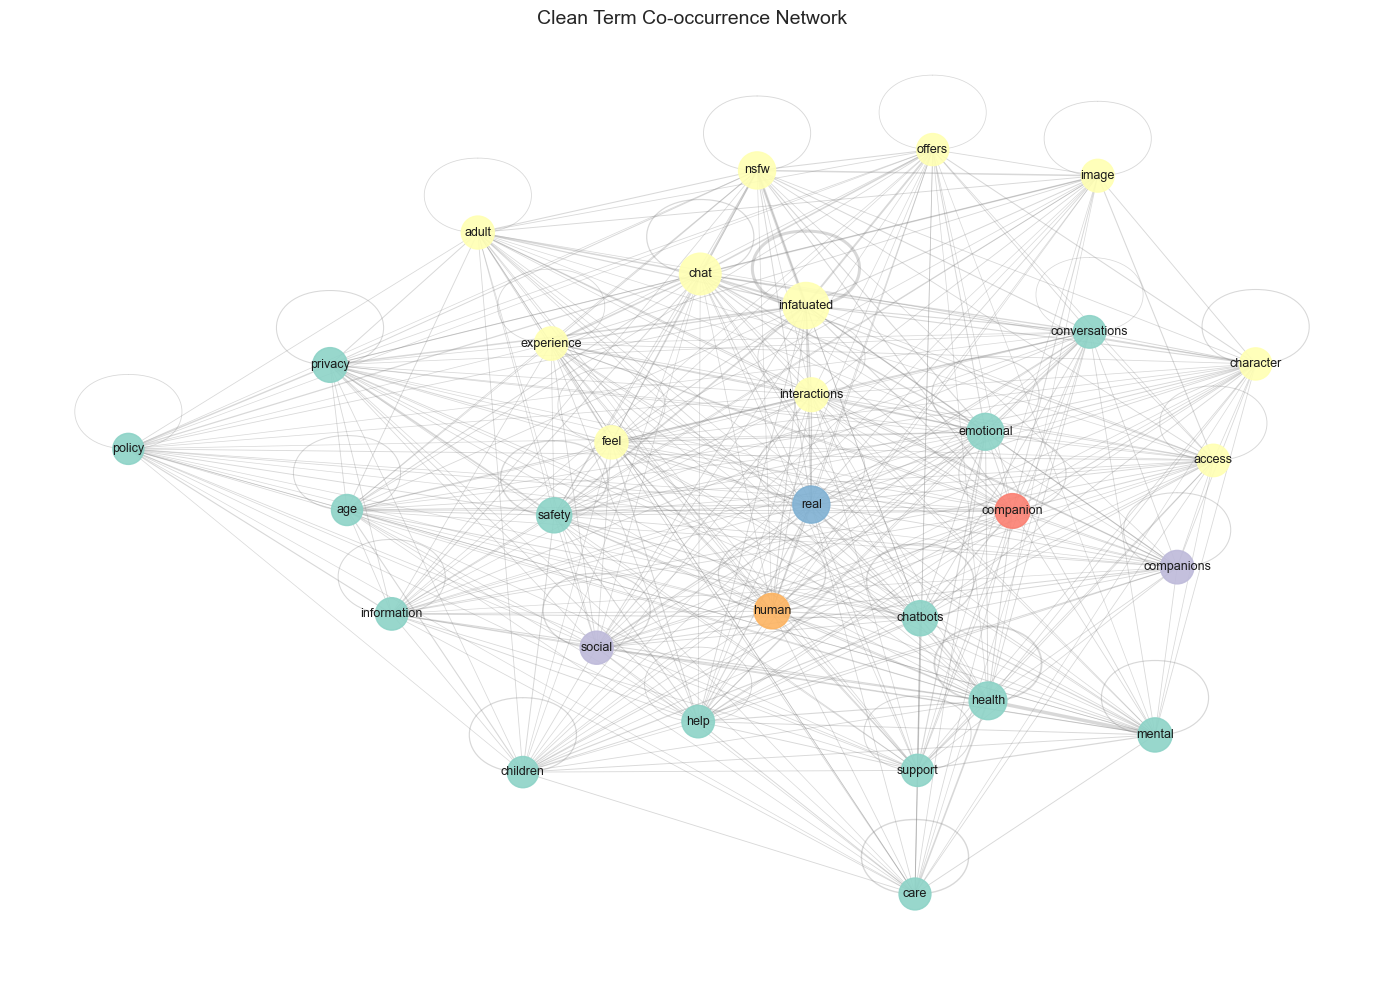

In [26]:
# ---------------------------------------------------------------------------
# SOCIAL NETWORK ANALYSIS — FINAL CLEAN VERSION (NO OVERLAP)
# ---------------------------------------------------------------------------

import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
import numpy as np
term_freq_df = pd.read_csv('ai_companionship_term_frequency_strict.csv')
# -------------------------------
# 1. Vocabulary
# -------------------------------
network_vocab = set(term_freq_df.head(60)['term'].tolist())

# -------------------------------
# 2. Window-based co-occurrence
# -------------------------------
edge_counter = Counter()
window_size = 4  # smaller = less dense

for txt in analysis_text_series:
    doc_terms = [t for t in tokenize_for_analysis(txt) if t in network_vocab]
    
    for i in range(len(doc_terms)):
        for j in range(i + 1, min(i + window_size, len(doc_terms))):
            a, b = sorted([doc_terms[i], doc_terms[j]])
            edge_counter[(a, b)] += 1

# -------------------------------
# 3. Build graph (STRONG FILTER)
# -------------------------------
G = nx.Graph()

min_edge_weight = 10  # 🔥 strong filter

for (a, b), w in edge_counter.items():
    if w >= min_edge_weight:
        G.add_edge(a, b, weight=w)

print(f'SNA nodes: {G.number_of_nodes()}, edges: {G.number_of_edges()}')

# -------------------------------
# 4. Centrality
# -------------------------------
if G.number_of_nodes() > 0:

    weighted_degree = dict(G.degree(weight='weight'))

    centrality_df = pd.DataFrame({
        'term': list(G.nodes()),
        'weighted_degree': [weighted_degree[n] for n in G.nodes()],
    }).sort_values('weighted_degree', ascending=False)

    display(centrality_df.head(20))

    # -------------------------------
    # 5. Reduce graph size
    # -------------------------------
    top_n = 30
    nodes_keep = centrality_df.head(top_n)['term'].tolist()
    subgraph = G.subgraph(nodes_keep).copy()

    # Keep largest component only
    if nx.number_connected_components(subgraph) > 1:
        largest_cc = max(nx.connected_components(subgraph), key=len)
        subgraph = subgraph.subgraph(largest_cc).copy()

    if subgraph.number_of_nodes() == 0:
        print("Graph empty after filtering")
    else:
        # -------------------------------
        # 6. Community detection
        # -------------------------------
        communities = list(nx.community.greedy_modularity_communities(subgraph))

        color_map = {}
        palette = plt.cm.Set3.colors  # softer + clearer

        for i, com in enumerate(communities):
            for node in com:
                color_map[node] = palette[i % len(palette)]

        node_colors = [color_map.get(n, "#cccccc") for n in subgraph.nodes()]

        # -------------------------------
        # 7. Layout (KEY FIX)
        # -------------------------------
        pos = nx.spring_layout(
            subgraph,
            k=3.5,          # 🔥 MUCH more spacing
            iterations=200, # stabilize layout
            seed=42
        )

        # -------------------------------
        # 8. Normalize sizes (CRITICAL FIX)
        # -------------------------------
        degrees = np.array([weighted_degree[n] for n in subgraph.nodes()])
        
        # Normalize between 300–900 ONLY
        node_sizes = 500 + (degrees - degrees.min()) / (degrees.max() - degrees.min() + 1e-6) * 600

        # Normalize edge width
        weights = np.array([subgraph[u][v]['weight'] for u, v in subgraph.edges()])
        edge_widths = 0.5 + (weights - weights.min()) / (weights.max() - weights.min() + 1e-6) * 2

        # -------------------------------
        # 9. Draw
        # -------------------------------
        plt.figure(figsize=(14, 10))

        nx.draw_networkx_nodes(
            subgraph,
            pos,
            node_size=node_sizes,
            node_color=node_colors,
            alpha=0.9
        )

        nx.draw_networkx_edges(
            subgraph,
            pos,
            width=edge_widths,
            edge_color='gray',
            alpha=0.3
        )

        # Label only top 15 (avoid clutter)
        label_nodes = centrality_df.head(30)['term'].tolist()

        nx.draw_networkx_labels(
            subgraph,
            pos,
            labels={n: n for n in label_nodes if n in subgraph.nodes()},
            font_size=9
        )

        plt.title("Clean Term Co-occurrence Network", fontsize=14)
        plt.axis('off')
        plt.tight_layout()
        plt.show()

else:
    print("Graph empty. Lower thresholds.")

## Topic Assignment and Reporting

This section operationalises the selected LDA model into reusable reporting assets. Rather than stopping at abstract topic weights, it assigns each article to a dominant topic, exposes representative examples, and exports topic-level files that can feed dashboards, appendices, or manual QA.

**Execution guidance:** Run this section after the main LDA comparison cell has selected `best_k`. If the session was interrupted, the reload cell below restores saved artefacts so you can continue the reporting workflow without recomputing every earlier step.

### Step 23 - Define the Topic Example Extraction Helper

**Objective:** Create a reusable function that assigns dominant topics to articles, labels topics with top terms, and extracts the strongest example articles for each topic.

**Rationale:** Topic models are only useful in reporting when they can be translated back into human-readable evidence. This helper bridges model output and business interpretation by packaging topic assignments, topic labels, and representative article examples into reusable tables.

**How to review this cell:** Note the row-count validation at the start of the function. That safeguard is important because topic assignments are only valid when the dataframe and document-term matrix describe the exact same documents in the same order.

In [110]:
def build_topic_example_table_from_existing_model(df, label, best_k_value, lda_model, dtm_matrix, feature_names, score_df, top_n_terms=8, examples_per_topic=3):
    if len(df) != dtm_matrix.shape[0]:
        raise ValueError('Row count mismatch: df and dtm_matrix must describe the same documents in the same order.')

    best_k_value = int(best_k_value)
    topic_probs = lda_model.transform(dtm_matrix)
    dominant_topic = topic_probs.argmax(axis=1)
    dominant_score = topic_probs.max(axis=1)

    assigned_df = df.copy().reset_index(drop=True)
    assigned_df['topic_id'] = dominant_topic + 1
    assigned_df['topic_score'] = dominant_score
    assigned_df['dataset_version'] = label

    topic_label_rows = []
    for topic_idx, topic_weights in enumerate(lda_model.components_):
        top_idx = topic_weights.argsort()[-top_n_terms:][::-1]
        topic_terms = [feature_names[i] for i in top_idx]
        topic_label_rows.append({
            'dataset_version': label,
            'best_k': best_k_value,
            'topic_id': topic_idx + 1,
            'topic_terms': ', '.join(topic_terms),
        })
    topic_labels_df = pd.DataFrame(topic_label_rows)

    assigned_df = assigned_df.merge(topic_labels_df, on='topic_id', how='left')
    assigned_df['content_preview'] = assigned_df['text'].fillna('').astype(str).str.replace(r'\s+', ' ', regex=True).str.slice(0, 650)

    example_rows = []
    for topic_id in sorted(assigned_df['topic_id'].dropna().unique()):
        topic_slice = assigned_df[assigned_df['topic_id'] == topic_id].sort_values('topic_score', ascending=False).head(examples_per_topic)
        for _, row in topic_slice.iterrows():
            example_rows.append({
                'dataset_version': label,
                'best_k': best_k_value,
                'topic_id': int(topic_id),
                'topic_terms': row['topic_terms'],
                'topic_score': float(row['topic_score']),
                'query': row.get('query', ''),
                'title': row.get('title', ''),
                'comment_or_content': row['content_preview'],
                'url': row.get('final_url', row.get('url', '')),
            })

    examples_df = pd.DataFrame(example_rows)
    return best_k_value, score_df.copy(), topic_labels_df, assigned_df, examples_df


### Step 24 - Produce Example Articles for Each Best-K Topic

**Objective:** Apply the dominant-topic assignment helper to the strict corpus and export representative articles for each selected topic.

**Rationale:** Example articles make the model auditable. They let reviewers verify that a topic label is supported by real articles and that the model is grouping documents in a way that is analytically meaningful.

**How to review this cell:** Inspect the displayed examples and ensure that high-scoring articles clearly match the reported topic terms. The exported CSV is suitable for appendices, human coding, or stakeholder review.

In [111]:
# Strict topic examples built from the main best-K LDA model
strict_best_k, strict_lda_scores, strict_topic_labels, strict_topic_assignments, strict_topic_examples = build_topic_example_table_from_existing_model(
    sentiment_df,
    label='strict',
    best_k_value=best_k,
    lda_model=models_by_k[best_k],
    dtm_matrix=dtm,
    feature_names=feature_names,
    score_df=model_scores_df,
    examples_per_topic=3,
)

strict_topic_examples_path = OUTPUT_DIR / 'strict_topic_example_articles.csv'
strict_topic_examples.to_csv(strict_topic_examples_path, index=False, encoding='utf-8-sig')

print(f'Strict best K (reused from main LDA): {strict_best_k}')
print(f'Saved strict topic examples to {strict_topic_examples_path}')
display(strict_topic_labels)
strict_topic_examples[['topic_id', 'topic_terms', 'query', 'title', 'topic_score', 'comment_or_content']]


Strict best K (reused from main LDA): 6
Saved strict topic examples to d:\ANALYTICS\WEBCRAWL\final\combined_outputs\strict_topic_example_articles.csv


,dataset_version,best_k,topic_id,topic_terms
0,strict,6,1,"chatbots, human, health, mental, mental health, social, emotional, companions"
1,strict,6,2,"information, public, intelligence, law, business, access, legal, human"
2,strict,6,3,"children, care, age, home, chatbots, companion, health, home care"
3,strict,6,4,"health, mental, mental health, care, real, support, gemini, help"
4,strict,6,5,"gemini, access, grok, images, online, companion, latest, claude"
5,strict,6,6,"chat, nsfw, emotional, privacy, image, adult, interactions, offers"


,topic_id,topic_terms,query,title,topic_score,comment_or_content
0,1,"chatbots, human, health, mental, mental health, social, emotional, companions",AI chatbot misinformation,Using your AI chatbot as a search engine? Be careful what you believe,0.998694,"- Digital - 4 min read Using your AI chatbot as a search engine? Be careful what you believe Governments have a history of spreading dangerous misinformation, as seen with rhub..."
1,1,"chatbots, human, health, mental, mental health, social, emotional, companions",AI companion emotional blackmail,The Dark Side of AI Companions: Emotional Manipulation,0.997995,Artificial Intelligence The Dark Side of AI Companions: Emotional Manipulation New research finds many AI companions guilt or pressure people to stay engaged. Posted September ...
2,1,"chatbots, human, health, mental, mental health, social, emotional, companions",ai companion apps,AI companion apps exacerbate teen mental health concerns,0.997655,"Feb 12, 2026 Troubling stories about dangerous encounters with chatbots continue to surface in the news, with two recent reports from NPR that focused on teen suicide and menta..."
3,2,"information, public, intelligence, law, business, access, legal, human",ai companion data breach,Why 2026 will be the year of governed cybersecurity AI,0.998835,"Cybersecurity spent years automating a staffing crisis. Now it must decide who governs the machines. The global average cost of a data breach fell to USD 4.44 million in 2025, ..."
4,2,"information, public, intelligence, law, business, access, legal, human",ai companion for students,AI no longer optional in universities but policy frameworks remain weak | Technology,0.998495,"AI no longer optional in universities but policy frameworks remain weak A new perspective paper reveals that universities worldwide are struggling to keep pace with the speed, ..."
5,2,"information, public, intelligence, law, business, access, legal, human",ai partner app,"Zapier and Rillet Partner on AI-Native Finance Stack, Connecting AI ERP to 8,000+ Apps",0.998238,"Zapier and Rillet Partner on AI-Native Finance Stack, Connecting AI ERP to 8,000+ Apps Integration gives finance teams a fully AI-native stack to orchestrate close, approvals, ..."
6,3,"children, care, age, home, chatbots, companion, health, home care",digital companion app,Australia forces porn sites to block under-18s,0.999740,Most Widely Read Newspaper Porn Kindly share this story: Australia’s online regulator warned porn websites they must block under-18s from Monday under sweeping new restrictions...
7,3,"children, care, age, home, chatbots, companion, health, home care",virtual companion app,Solving the home care quandary,0.998878,"A good deal of sunshine. High 74F. Winds WSW at 5 to 10 mph.. Generally clear skies. Low 46F. Winds light and variable. Updated: April 7, 2026 @ 10:52 am Medicaid underwrites h..."
8,3,"children, care, age, home, chatbots, companion, health, home care",virtual companion app,Solving the home care quandary,0.998867,"e-Edition Sign up for email newsletters to submit an obituary Please email classads@advocate-news.com or call 707-380-1152. Please include your name, mailing address, and phone..."
9,4,"health, mental, mental health, care, real, support, gemini, help",AI companion Nigeria mental health,Can AI help your mental health? The truth behind the trend - The Nation Newspaper,0.999392,"Technology February 17, 2026 by Ozioma Emeka AI is no longer just helping people write emails or generate ideas. Increasingly, people are using it for something more personal. ..."


### Step 25 - Restore Topic Outputs After a Kernel Reset

**Objective:** Reload saved topic-modelling artefacts from disk so topic-level reporting can continue without recomputing the full model stack.

**Rationale:** Long analytical notebooks should be resumable. This cell improves operational resilience by recovering the best-`K` metadata, topic labels, examples, and per-topic article exports after an interrupted session.

**How to review this cell:** Check the loaded row counts and read the final note carefully: CSV reload restores tables, but not the in-memory LDA object itself. Re-run the modelling cells if you need to regenerate assignments rather than simply continue reporting.

In [ ]:
# Reload CSV-backed strict topic artifacts so the best-K section can be resumed after a kernel reset
lda_scores_path = NOTEBOOK_DIR / LDA_MODEL_SCORES_CSV
lda_topic_terms_path = NOTEBOOK_DIR / LDA_TOPIC_TERMS_CSV
strict_topic_output_dir = OUTPUT_DIR / 'strict_topic_category_exports'
strict_topic_export_summary_path = strict_topic_output_dir / 'strict_topic_category_summary.csv'
strict_topic_examples_path = OUTPUT_DIR / 'strict_topic_example_articles.csv'

model_scores_df = pd.read_csv(lda_scores_path)
if 'combined_rank' in model_scores_df.columns:
    best_k = int(model_scores_df.sort_values('combined_rank').iloc[0]['k'])
else:
    best_k = int(model_scores_df.iloc[0]['k'])

lda_topic_terms_df = pd.read_csv(lda_topic_terms_path) if lda_topic_terms_path.exists() else pd.DataFrame()

strict_topic_export_summary = pd.read_csv(strict_topic_export_summary_path) if strict_topic_export_summary_path.exists() else pd.DataFrame()
strict_best_k = int(strict_topic_export_summary['best_k'].iloc[0]) if not strict_topic_export_summary.empty and 'best_k' in strict_topic_export_summary.columns else best_k

strict_topic_csv_paths = []
if not strict_topic_export_summary.empty and 'output_csv' in strict_topic_export_summary.columns:
    strict_topic_csv_paths = [Path(p) for p in strict_topic_export_summary['output_csv'].dropna().tolist()]

strict_topic_frames = [pd.read_csv(path) for path in strict_topic_csv_paths if path.exists()]
strict_topic_assignments = pd.concat(strict_topic_frames, ignore_index=True) if strict_topic_frames else pd.DataFrame()

if not strict_topic_assignments.empty and {'topic_id', 'topic_terms'}.issubset(strict_topic_assignments.columns):
    strict_topic_labels = (
        strict_topic_assignments[['topic_id', 'topic_terms']]
        .drop_duplicates()
        .sort_values('topic_id')
        .assign(dataset_version='strict', best_k=strict_best_k)
        [['dataset_version', 'best_k', 'topic_id', 'topic_terms']]
        .reset_index(drop=True)
    )
else:
    strict_topic_labels = pd.DataFrame(columns=['dataset_version', 'best_k', 'topic_id', 'topic_terms'])

strict_topic_examples = pd.read_csv(strict_topic_examples_path) if strict_topic_examples_path.exists() else pd.DataFrame()
strict_lda_scores = model_scores_df.copy()

print(f'Loaded best_k={best_k} from {lda_scores_path}')
print(f'Loaded LDA topic terms rows: {len(lda_topic_terms_df)}')
print(f'Loaded strict topic summary rows: {len(strict_topic_export_summary)}')
print(f'Loaded strict topic assignments rows: {len(strict_topic_assignments)}')
print(f'Loaded strict topic examples rows: {len(strict_topic_examples)}')
if 'models_by_k' not in globals() or best_k not in models_by_k:
    print('Note: CSV reload restores tables, but not the in-memory LDA model object. Re-run the earlier LDA model cells if you need to recompute topic assignments from scratch.')


### Step 26 - Export One Deliverable CSV per Topic

**Objective:** Split the strict corpus into one CSV per dominant topic and create an index table that records the file path and article count for each export.

**Rationale:** Topic-specific files are convenient for manual review, annotation, dashboard ingestion, and appendix-ready evidence packs. The summary table also acts as a lightweight catalogue of every topic deliverable produced by the notebook.

**How to review this cell:** Confirm that every topic received an output file, that filenames are clean and readable, and that the article counts in the summary align with the assignment table.

In [112]:
# Separate cleaned strict news into one CSV per best-K topic/category
strict_topic_output_dir = OUTPUT_DIR / 'strict_topic_category_exports'
strict_topic_output_dir.mkdir(parents=True, exist_ok=True)

def slugify_topic_label(text: str) -> str:
    text = re.sub(r'[^a-z0-9]+', '_', str(text).lower())
    return text.strip('_')[:80]

strict_topic_export_rows = []

for topic_id in sorted(strict_topic_assignments['topic_id'].dropna().unique()):
    topic_id = int(topic_id)
    topic_slice = strict_topic_assignments[strict_topic_assignments['topic_id'] == topic_id].copy()

    if topic_slice.empty:
        continue

    topic_terms_series = topic_slice['topic_terms'].dropna() if 'topic_terms' in topic_slice.columns else pd.Series(dtype='object')
    topic_terms = topic_terms_series.iloc[0] if not topic_terms_series.empty else f'topic_{topic_id}'
    topic_slug = slugify_topic_label(topic_terms) or f'topic_{topic_id}'
    output_path = strict_topic_output_dir / f'strict_topic_{topic_id}_{topic_slug}.csv'

    topic_slice.to_csv(output_path, index=False, encoding='utf-8-sig')

    strict_topic_export_rows.append({
        'best_k': strict_best_k,
        'topic_id': topic_id,
        'topic_terms': topic_terms,
        'article_count': len(topic_slice),
        'output_csv': str(output_path),
    })

strict_topic_export_summary = pd.DataFrame(strict_topic_export_rows).sort_values('topic_id').reset_index(drop=True)
strict_topic_export_summary_path = strict_topic_output_dir / 'strict_topic_category_summary.csv'
strict_topic_export_summary.to_csv(strict_topic_export_summary_path, index=False, encoding='utf-8-sig')

print(f'Strict best K used for category export: {strict_best_k}')
print(f'Saved topic-separated CSV files to: {strict_topic_output_dir}')
print(f'Saved export summary to: {strict_topic_export_summary_path}')
strict_topic_export_summary


Strict best K used for category export: 6
Saved topic-separated CSV files to: d:\ANALYTICS\WEBCRAWL\final\combined_outputs\strict_topic_category_exports
Saved export summary to: d:\ANALYTICS\WEBCRAWL\final\combined_outputs\strict_topic_category_exports\strict_topic_category_summary.csv


,best_k,topic_id,topic_terms,article_count,output_csv
0,6,1,"chatbots, human, health, mental, mental health, social, emotional, companions",171,d:\ANALYTICS\WEBCRAWL\final\combined_outputs\strict_topic_category_exports\strict_topic_1_chatbots_human_health_mental_mental_health_social_emotional_companions.csv
1,6,2,"information, public, intelligence, law, business, access, legal, human",121,d:\ANALYTICS\WEBCRAWL\final\combined_outputs\strict_topic_category_exports\strict_topic_2_information_public_intelligence_law_business_access_legal_human.csv
2,6,3,"children, care, age, home, chatbots, companion, health, home care",37,d:\ANALYTICS\WEBCRAWL\final\combined_outputs\strict_topic_category_exports\strict_topic_3_children_care_age_home_chatbots_companion_health_home_care.csv
3,6,4,"health, mental, mental health, care, real, support, gemini, help",48,d:\ANALYTICS\WEBCRAWL\final\combined_outputs\strict_topic_category_exports\strict_topic_4_health_mental_mental_health_care_real_support_gemini_help.csv
4,6,5,"gemini, access, grok, images, online, companion, latest, claude",121,d:\ANALYTICS\WEBCRAWL\final\combined_outputs\strict_topic_category_exports\strict_topic_5_gemini_access_grok_images_online_companion_latest_claude.csv
5,6,6,"chat, nsfw, emotional, privacy, image, adult, interactions, offers",5,d:\ANALYTICS\WEBCRAWL\final\combined_outputs\strict_topic_category_exports\strict_topic_6_chat_nsfw_emotional_privacy_image_adult_interactions_offers.csv


### Step 27 - Summarise Sentiment by Topic

**Objective:** Aggregate sentiment counts and average compound scores within each dominant topic, then visualise the percentage mix of positive, neutral, and negative articles.

**Rationale:** This is the synthesis cell that joins thematic structure with affective tone. It shows not only what the media is discussing about AI companionship, but also how each topic is framed emotionally.

**How to review this cell:** Use the summary table and stacked chart together. The table supports precise reporting, while the chart highlights whether certain topics skew more positive or more negative than the corpus baseline.

Sentiment label percentage for each topic:


sentiment_label,topic_id,topic_terms,positive,neutral,negative
0,1,"chatbots, human, health, mental, mental health, social, emotional, companions",77.19,1.17,21.64
1,2,"information, public, intelligence, law, business, access, legal, human",87.60,0.00,12.40
2,3,"children, care, age, home, chatbots, companion, health, home care",75.68,0.00,24.32
3,4,"health, mental, mental health, care, real, support, gemini, help",66.67,0.00,33.33
4,5,"gemini, access, grok, images, online, companion, latest, claude",76.86,2.48,20.66
5,6,"chat, nsfw, emotional, privacy, image, adult, interactions, offers",100.00,0.00,0.00


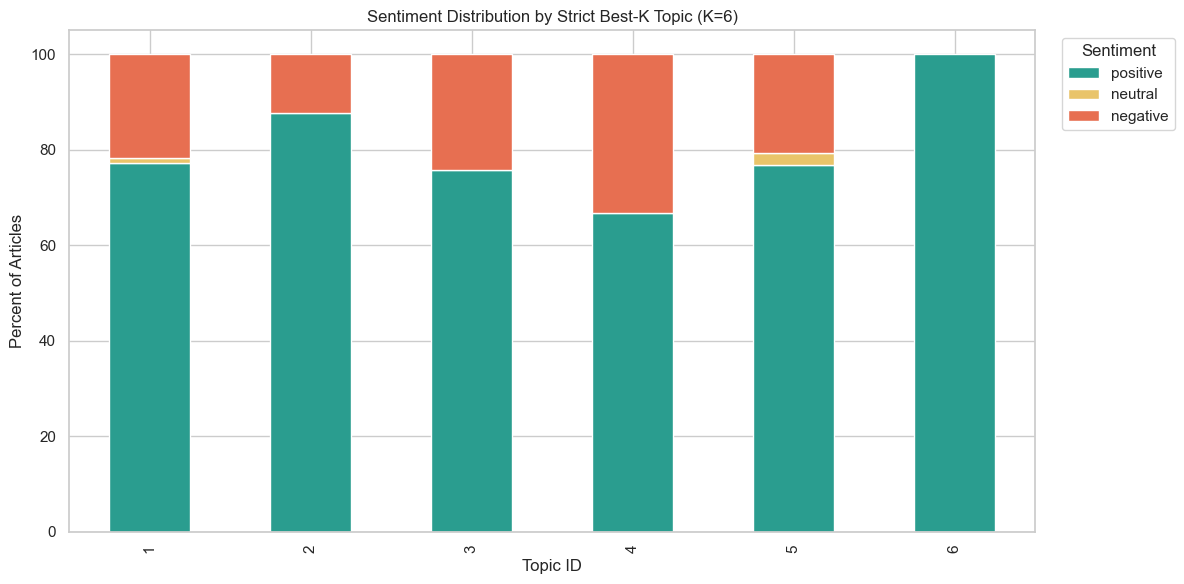

Strict best K used for topic sentiment analysis: 6
Saved topic sentiment summary to: d:\ANALYTICS\WEBCRAWL\final\combined_outputs\strict_topic_sentiment_summary.csv


,best_k,topic_id,topic_terms,sentiment_label,article_count,topic_total_articles,sentiment_pct,avg_compound
0,6,1,"chatbots, human, health, mental, mental health, social, emotional, companions",negative,37,171,21.64,-0.9195
1,6,1,"chatbots, human, health, mental, mental health, social, emotional, companions",neutral,2,171,1.17,0.0129
2,6,1,"chatbots, human, health, mental, mental health, social, emotional, companions",positive,132,171,77.19,0.9498
3,6,2,"information, public, intelligence, law, business, access, legal, human",negative,15,121,12.40,-0.9336
4,6,2,"information, public, intelligence, law, business, access, legal, human",positive,106,121,87.60,0.9602
5,6,3,"children, care, age, home, chatbots, companion, health, home care",negative,9,37,24.32,-0.8545
6,6,3,"children, care, age, home, chatbots, companion, health, home care",positive,28,37,75.68,0.9244
7,6,4,"health, mental, mental health, care, real, support, gemini, help",negative,16,48,33.33,-0.8503
8,6,4,"health, mental, mental health, care, real, support, gemini, help",positive,32,48,66.67,0.9753
9,6,5,"gemini, access, grok, images, online, companion, latest, claude",negative,25,121,20.66,-0.7325


In [28]:
# Sentiment analysis per topic using the strict best-K topic assignments
strict_topic_sentiment_path = OUTPUT_DIR / 'strict_topic_sentiment_summary.csv'

strict_topic_sentiment_summary = (
    strict_topic_assignments
    .dropna(subset=['topic_id'])
    .assign(topic_id=lambda df: df['topic_id'].astype(int))
    .groupby(['topic_id', 'topic_terms', 'sentiment_label'], dropna=False)
    .agg(
        article_count=('sentiment_label', 'size'),
        avg_compound=('compound', 'mean'),
    )
    .reset_index()
)

topic_totals = (
    strict_topic_assignments
    .dropna(subset=['topic_id'])
    .assign(topic_id=lambda df: df['topic_id'].astype(int))
    .groupby(['topic_id', 'topic_terms'], dropna=False)
    .size()
    .reset_index(name='topic_total_articles')
)

strict_topic_sentiment_summary = (
    strict_topic_sentiment_summary
    .merge(topic_totals, on=['topic_id', 'topic_terms'], how='left')
    .assign(
        best_k=strict_best_k,
        sentiment_pct=lambda df: (df['article_count'] / df['topic_total_articles'] * 100).round(2),
        avg_compound=lambda df: df['avg_compound'].round(4),
    )
    [['best_k', 'topic_id', 'topic_terms', 'sentiment_label', 'article_count', 'topic_total_articles', 'sentiment_pct', 'avg_compound']]
    .sort_values(['topic_id', 'sentiment_label'])
    .reset_index(drop=True)
)

strict_topic_sentiment_summary.to_csv(strict_topic_sentiment_path, index=False, encoding='utf-8-sig')

plot_order = ['positive', 'neutral', 'negative']
available_labels = [label for label in plot_order if label in strict_topic_sentiment_summary['sentiment_label'].dropna().unique()]
plot_df = (
    strict_topic_sentiment_summary
    .pivot_table(index='topic_id', columns='sentiment_label', values='sentiment_pct', fill_value=0)
    .reindex(columns=available_labels)
)

topic_sentiment_pct_table = (
    strict_topic_sentiment_summary
    .pivot_table(
        index=['topic_id', 'topic_terms'],
        columns='sentiment_label',
        values='sentiment_pct',
        fill_value=0,
    )
    .reindex(columns=plot_order, fill_value=0)
    .reset_index()
)

print('Sentiment label percentage for each topic:')
display(topic_sentiment_pct_table)

if not plot_df.empty:
    ax = plot_df.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#2A9D8F', '#E9C46A', '#E76F51'][:len(plot_df.columns)])
    ax.set_title(f'Sentiment Distribution by Strict Best-K Topic (K={strict_best_k})')
    ax.set_xlabel('Topic ID')
    ax.set_ylabel('Percent of Articles')
    ax.legend(title='Sentiment', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

print(f'Strict best K used for topic sentiment analysis: {strict_best_k}')
print(f'Saved topic sentiment summary to: {strict_topic_sentiment_path}')
strict_topic_sentiment_summary
